# Онлайн-олимпиада для школьников: очистка данных, региональные отчёты и выводы

**Данные:** `olympiad_results.csv` — одна строка на одно прохождение, 12 заданий, 10 регионов. Словарь — `olympiad_data_dictionary.csv`.

**Что делаем в ноутбуке**

1. Загружаем таблицу и смотрим, что в ней сломано.
2. Чистим: регионы, дубликаты, типы, подозрительные сессии, пропуски.
3. Считаем производные метрики.
4. Разбираем сложность заданий.
5. Описываем аудиторию и вовлечённость.
6. Собираем мини-отчёты по регионам (плюс PDF на каждый регион).
7. Проверяем гипотезы статистикой.
8. Сводим аномалии и выводы для бизнеса.

Весь ноутбук выполняется сверху вниз без ручных правок. На выходе в папке рядом появятся `olympiad_clean.csv`, `figures/` и `reports/`.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
ACCENT, GREY, WARN = "#2F5D8A", "#B8C2CC", "#C8553D"

# файл ищем рядом с ноутбуком, затем уровнем выше
DATA = next(p for p in [Path("olympiad_results.csv"), Path("../olympiad_results.csv")] if p.exists())
DICT = DATA.with_name("olympiad_data_dictionary.csv")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
REP = Path("reports"); REP.mkdir(exist_ok=True)

N_TASKS = 12
ANS = [f"Task_{i}_answer" for i in range(1, N_TASKS + 1)]
COR = [f"Task_{i}_correct" for i in range(1, N_TASKS + 1)]
TIM = [f"Task_{i}_time_spent" for i in range(1, N_TASKS + 1)]

## 1. Загрузка и первичный осмотр

Читаем всё как есть, без подсказок типов, — чтобы увидеть дефекты в исходном виде.

In [2]:
raw = pd.read_csv(DATA)
print("Размер:", raw.shape)
display(raw.head(3))
print(raw.dtypes.value_counts())

Размер: (8037, 46)


,student_id,region,school_number,grade,start_time,end_time,Task_1_answer,Task_1_correct,Task_1_time_spent,Task_2_answer,Task_2_correct,Task_2_time_spent,Task_3_answer,Task_3_correct,Task_3_time_spent,Task_4_answer,Task_4_correct,Task_4_time_spent,Task_5_answer,Task_5_correct,Task_5_time_spent,Task_6_answer,Task_6_correct,Task_6_time_spent,Task_7_answer,Task_7_correct,Task_7_time_spent,Task_8_answer,Task_8_correct,Task_8_time_spent,Task_9_answer,Task_9_correct,Task_9_time_spent,Task_10_answer,Task_10_correct,Task_10_time_spent,Task_11_answer,Task_11_correct,Task_11_time_spent,Task_12_answer,Task_12_correct,Task_12_time_spent,total_score,device_type,attempts_count,disconnects
0,S200000,Краснодар,9,11,2026-04-10 11:10:00,2026-04-10 11:25:19,4.0,0.0,93.0,1.0,0.0,75.0,2.0,0.0,65.0,1.0,0.0,81.0,1.0,0.0,66.0,1.0,0.0,47.0,2.0,0.0,109.0,3.0,1.0,30.0,3.0,1.0,59.0,1.0,1.0,86.0,2.0,0.0,84.0,4.0,0.0,124.0,3,desktop,2,0
1,S200001,Ростов-на-Дону,44,9,2026-04-10 10:30:00,2026-04-10 10:44:19,3.0,0.0,105.0,2.0,0.0,71.0,2.0,0.0,59.0,1.0,1.0,117.0,3.0,0.0,59.0,3.0,1.0,60.0,4.0,1.0,67.0,1.0,1.0,76.0,1.0,0.0,33.0,2.0,1.0,76.0,4.0,1.0,73.0,4.0,0.0,63.0,6,mobile,2,0
2,S200002,Екатеринбург,44,9,2026-04-10 10:25:00,2026-04-10 10:38:33,4.0,1.0,60.0,3.0,0.0,98.0,2.0,0.0,67.0,1.0,1.0,26.0,3.0,0.0,86.0,3.0,1.0,81.0,4.0,1.0,84.0,2.0,1.0,71.0,1.0,0.0,62.0,NaN,NaN,NaN,1.0,1.0,101.0,1.0,1.0,77.0,7,mobile,1,1


float64    36
str         5
int64       5
Name: count, dtype: int64


In [3]:
pd.read_csv(DICT)

,Столбец,Описание
0,student_id,Уникальный идентификатор ученика
1,region,Регион школы ученика (содержит опечатки и разн...
2,school_number,Номер школы внутри региона
3,grade,Класс ученика (5-11)
4,start_time,Время начала прохождения олимпиады
5,end_time,Время окончания прохождения олимпиады
6,Task_N_answer,Выбранный вариант ответа на задание N (1-4)
7,Task_N_correct,Признак правильности ответа на задание N (1 - ...
8,Task_N_time_spent,"Время, затраченное на задание N, в секундах"
9,total_score,Итоговый балл за олимпиаду (в части строк тип ...


### 1.1 Пропуски
Пропуски есть только в блоках заданий, и в каждом задании `answer`, `correct` и `time_spent` пропущены одновременно. Значит, это не потеря данных, а пропущенное учеником задание.

In [4]:
na = raw.isna().sum()
na = na[na > 0]
print("Столбцов с пропусками:", len(na), "из", raw.shape[1])

# в каждом задании все три поля пустые одновременно?
same_mask = all(
    (raw[a].isna() == raw[c].isna()).all() and (raw[a].isna() == raw[t].isna()).all()
    for a, c, t in zip(ANS, COR, TIM)
)
print("answer / correct / time_spent пропущены синхронно:", same_mask)
na_tasks = raw[COR].isna().sum().rename("пропусков").to_frame()
na_tasks["доля"] = (na_tasks["пропусков"] / len(raw)).round(3)
na_tasks.T

Столбцов с пропусками: 36 из 46
answer / correct / time_spent пропущены синхронно: True


,Task_1_correct,Task_2_correct,Task_3_correct,Task_4_correct,Task_5_correct,Task_6_correct,Task_7_correct,Task_8_correct,Task_9_correct,Task_10_correct,Task_11_correct,Task_12_correct
пропусков,318.00,341.000,315.000,310.000,299.000,327.000,312.000,316.000,313.000,316.000,287.000,321.00
доля,0.04,0.042,0.039,0.039,0.037,0.041,0.039,0.039,0.039,0.039,0.036,0.04


### 1.2 Дубликаты, регионы, типы

In [5]:
print("Полных дубликатов строк:", raw.duplicated().sum())
print("Повторов student_id:     ", raw["student_id"].duplicated().sum())
print("Повторы student_id — это те же самые строки:",
      raw.duplicated().sum() == raw["student_id"].duplicated().sum())

Полных дубликатов строк: 37
Повторов student_id:      37
Повторы student_id — это те же самые строки: True


In [6]:
raw["region"].value_counts()

region
Уфа                847
Краснодар          807
Воронеж            807
Ростов-на-Дону     804
Новосибирск        791
Пермь              766
Екатеринбург       754
Казань             748
Москва             736
Санкт-Петербург    718
г.Казань            39
СПб                 37
казань              34
мск                 31
Санкт Петербург     27
москва              26
спб                 26
г. Москва           20
Moskva              19
Name: count, dtype: int64

Вместо 10 регионов в таблице 19 написаний. Москва встречается в пяти вариантах (`мск`, `москва`, `г. Москва`, `Moskva`), Петербург — в четырёх, Казань — в трёх.

In [7]:
# total_score: в словаре сказано, что в части строк это строка. Проверяем исходный текст.
ts_raw = pd.read_csv(DATA, usecols=["total_score"], dtype=str)["total_score"]
bad_ts = ts_raw[~ts_raw.str.fullmatch(r"\s*\d+\s*", na=False)]
print("total_score, нечисловых значений в исходном файле:", len(bad_ts))
print("Тип после чтения pandas:", raw["total_score"].dtype)

total_score, нечисловых значений в исходном файле: 0
Тип после чтения pandas: int64


In [8]:
print("grade:", sorted(raw["grade"].unique()))
print("device_type:", raw["device_type"].unique())
print("attempts_count:", sorted(raw["attempts_count"].unique()), "| disconnects:", sorted(raw["disconnects"].unique()))
print("Варианты ответа:", sorted(raw[ANS].stack().unique()))
print("school_number: от", raw["school_number"].min(), "до", raw["school_number"].max())
print("start_time и end_time хранятся как:", raw["start_time"].dtype)

grade: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
device_type: <StringArray>
['desktop', 'mobile', 'tablet']
Length: 3, dtype: str
attempts_count: [np.int64(1), np.int64(2)] | disconnects: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Варианты ответа: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(nan)]
school_number: от 1 до 59
start_time и end_time хранятся как: str


**Итог аудита**

| Дефект | Масштаб | Что делаем |
|---|---|---|
| Разные написания регионов | 259 строк, 9 лишних вариантов | нормализуем к 10 каноническим названиям |
| Полные дубликаты строк | 37 | удаляем |
| Время хранится текстом | 2 столбца | переводим в datetime |
| `total_score` может прийти строкой | в этой выгрузке 0 строк, но защищаемся | `pd.to_numeric` + сверка с суммой `correct` |
| Пропущенные задания | ~4% ячеек по каждому заданию | оставляем как «пропуск», в балле считаем за 0 |
| Сверхбыстрые сессии | ищем ниже | удаляем |

В `grade`, `device_type`, `attempts_count`, `disconnects`, вариантах ответа и номерах школ недопустимых значений нет.

## 2. Очистка

### 2.1 Регионы
Нормализуем не ручным словарём на каждую опечатку, а через ключ: нижний регистр, без «г.», без пробелов и дефисов, транслит латиницы. Потом ключ сопоставляем с каноническим списком. Так новая опечатка вида «г Санкт-Петербург» тоже поймается.

In [9]:
CANON = ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург", "Новосибирск",
         "Краснодар", "Ростов-на-Дону", "Уфа", "Пермь", "Воронеж"]
ALIASES = {"мск": "Москва", "moskva": "Москва", "moscow": "Москва",
           "спб": "Санкт-Петербург", "питер": "Санкт-Петербург"}

def region_key(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"^г\.?\s*", "", s)          # «г.Казань», «г. Москва»
    s = re.sub(r"[\s\-\.]+", "", s)          # пробелы, дефисы, точки
    return s

KEY2CANON = {region_key(c): c for c in CANON}
KEY2CANON.update({region_key(k): v for k, v in ALIASES.items()})

def normalize_region(s):
    return KEY2CANON.get(region_key(s), np.nan)

df = raw.copy()
df["region_raw"] = df["region"]
df["region"] = df["region"].map(normalize_region)

print("Не распознано:", df["region"].isna().sum())
display(pd.crosstab(df["region_raw"], df["region"]).loc[lambda x: x.index.difference(CANON)].replace(0, "").T.loc[lambda x: (x != "").any(axis=1)])
df["region"].value_counts()

Не распознано: 0


region_raw,Moskva,СПб,Санкт Петербург,г. Москва,г.Казань,казань,москва,мск,спб
region,,,,,,,,,
Казань,,,,,39,34,,,
Москва,19,,,20,,,26,31,
Санкт-Петербург,,37,27,,,,,,26


region
Уфа                847
Москва             832
Казань             821
Санкт-Петербург    808
Краснодар          807
Воронеж            807
Ростов-на-Дону     804
Новосибирск        791
Пермь              766
Екатеринбург       754
Name: count, dtype: int64

### 2.2 Дубликаты и типы

In [10]:
log = [("Исходные строки", len(df))]

df = df.drop_duplicates(subset=[c for c in raw.columns]).copy()
log.append(("После удаления дубликатов", len(df)))
assert df["student_id"].is_unique

df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")
df["total_score"] = pd.to_numeric(df["total_score"].astype(str).str.strip(), errors="coerce")
# correct и time оставляем float64: NaN = пропуск, так удобнее считать средние
df[COR] = df[COR].astype("float64")
df[TIM] = df[TIM].astype("float64")
df[ANS] = df[ANS].astype("Int64")  # целый тип с поддержкой пропусков
for c in ["grade", "school_number", "attempts_count", "disconnects", "total_score"]:
    df[c] = df[c].astype("Int64")
df["device_type"] = df["device_type"].astype("category")

print("Непарсящихся дат:", df[["start_time", "end_time"]].isna().sum().sum())
print("Непарсящихся баллов:", df["total_score"].isna().sum())

# Сверка балла с ответами: пропуск считаем за 0
score_check = df[COR].fillna(0).sum(axis=1).astype(int)
print("Строк, где total_score ≠ сумме верных ответов:", (score_check != df["total_score"]).sum())

Непарсящихся дат: 0
Непарсящихся баллов: 0
Строк, где total_score ≠ сумме верных ответов: 0


### 2.3 Длительность и подозрительные сессии
Длительность сессии (`end_time − start_time`) до секунды совпадает с суммой времени по заданиям — это хорошая новость, счётчики времени согласованы. Теперь смотрим распределение.

Максимальное расхождение длительности и суммы по заданиям, сек: 0.0
Сессий с нулевой или отрицательной длительностью: 0


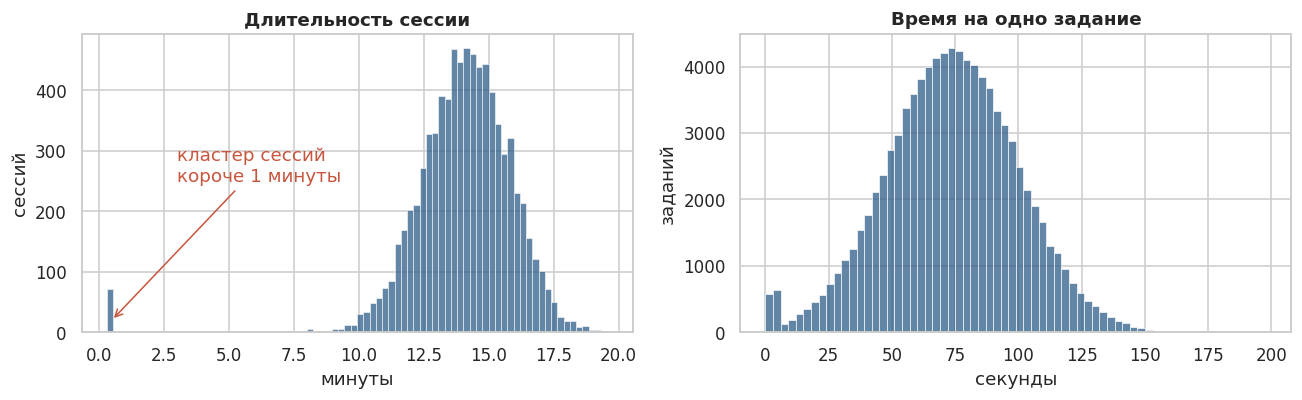

duration_sec
(0, 60]          72
(60, 120]         0
(120, 300]        0
(300, 400]        0
(400, 500]        8
(500, 600]       46
(600, 800]     2420
(800, 1200]    5454
Name: count, dtype: int64


In [11]:
df["duration_sec"] = (df["end_time"] - df["start_time"]).dt.total_seconds()
df["sum_task_time"] = df[TIM].sum(axis=1).astype(float)
print("Максимальное расхождение длительности и суммы по заданиям, сек:",
      (df["duration_sec"] - df["sum_task_time"]).abs().max())
print("Сессий с нулевой или отрицательной длительностью:", (df["duration_sec"] <= 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(df["duration_sec"] / 60, bins=80, ax=axes[0], color=ACCENT)
axes[0].set(title="Длительность сессии", xlabel="минуты", ylabel="сессий")
axes[0].annotate("кластер сессий\nкороче 1 минуты", xy=(0.5, 20), xytext=(3, 250),
                 arrowprops=dict(arrowstyle="->", color=WARN), color=WARN)
per_task = df[TIM].stack().astype(float)
sns.histplot(per_task, bins=range(0, 200, 3), ax=axes[1], color=ACCENT)
axes[1].set(title="Время на одно задание", xlabel="секунды", ylabel="заданий")
plt.tight_layout(); plt.savefig(FIG / "01_duration.png", bbox_inches="tight"); plt.show()

print(pd.cut(df["duration_sec"], [0, 60, 120, 300, 400, 500, 600, 800, 1200]).value_counts().sort_index())

Между 31 секундой и 7,8 минуты — ни одной сессии. Группа из 72 сессий (после удаления дубликатов) длится 18–31 секунду: примерно 2 секунды на задание, при том что медиана по всем остальным — около 73 секунд. Прочитать условие олимпиадной задачи за 2 секунды нельзя.

Проверим, похоже ли это на честное решение или на случайное «прокликивание». При четырёх вариантах ответа угадывание даёт в среднем 12 × 0,25 = 3 балла.

In [12]:
FAST_THRESHOLD_SEC = 120  # с запасом: реальный разрыв — от 31 с до 400+ с
df["is_fast"] = df["duration_sec"] < FAST_THRESHOLD_SEC

cmp = df.groupby("is_fast").agg(
    сессий=("student_id", "size"),
    средний_балл=("total_score", "mean"),
    медиана_длительности_сек=("duration_sec", "median"),
    сек_на_задание=("sum_task_time", lambda s: s.mean() / N_TASKS),
    доля_пропусков=("Task_1_correct", lambda s: np.nan),
).round(2)
cmp["доля_пропусков"] = df.groupby("is_fast")[COR].apply(lambda x: x.isna().mean().mean()).round(3)
cmp.index = ["обычные", "сверхбыстрые"]
display(cmp)

fast = df[df["is_fast"]]
t = stats.ttest_1samp(fast["total_score"].astype(float), 3.0)
print(f"Средний балл сверхбыстрых: {fast['total_score'].mean():.2f} против 3,0 при угадывании; t-тест p = {t.pvalue:.2f}")
print("Регионы сверхбыстрых сессий:"); print(fast["region"].value_counts().to_dict())

,сессий,средний_балл,медиана_длительности_сек,сек_на_задание,доля_пропусков
обычные,7928,5.55,849.0,70.61,0.039
сверхбыстрые,72,2.78,24.0,2.01,0.000


Средний балл сверхбыстрых: 2.78 против 3,0 при угадывании; t-тест p = 0.23
Регионы сверхбыстрых сессий:
{'Воронеж': 11, 'Казань': 10, 'Новосибирск': 9, 'Ростов-на-Дону': 9, 'Пермь': 6, 'Москва': 6, 'Екатеринбург': 6, 'Санкт-Петербург': 5, 'Краснодар': 5, 'Уфа': 5}


Сверхбыстрые сессии отвечают на все 12 заданий без единого пропуска, тратят около 2 секунд на задание, а их средний балл статистически неотличим от случайного угадывания. Это либо тестовые прогоны и автотесты, либо прокликивание ради участия. В аналитике успеваемости им не место, удаляем. Отдельно фиксируем для продукта: такие сессии надо ловить на лету.

Порог 120 секунд выбран с запасом: реальный разрыв в данных — от 31 до 400+ секунд, поэтому результат от точного значения порога не зависит.

Отдельных маркеров тестовых аккаунтов (особых ID, школ, регионов) в выгрузке нет: все ID идут в одном формате `S2xxxxx`, все школы в диапазоне 1–59.

In [13]:
df = df[~df["is_fast"]].drop(columns="is_fast").copy()
log.append(("После удаления сверхбыстрых сессий", len(df)))

# Короткие ответы (≤ 5 с) внутри нормальных сессий оставляем: это отдельные задания, а не вся сессия
short = (df[TIM] <= 5).sum().sum()
print(f"Ответов быстрее 5 секунд внутри обычных сессий: {short} ({short / df[TIM].notna().sum().sum():.2%}) — оставляем, но помечаем")

Ответов быстрее 5 секунд внутри обычных сессий: 350 (0.38%) — оставляем, но помечаем


### 2.4 Пропуски
Пропуск задания — это поведение ученика, а не дыра в данных. Поэтому не заполняем его средним или модой, а:
* `correct` оставляем `NaN` для анализа «решаемости среди ответивших» и отдельно считаем флаг пропуска;
* в баллах пропуск = 0, как и в исходном `total_score`.

In [14]:
for i in range(1, N_TASKS + 1):
    df[f"Task_{i}_skipped"] = df[f"Task_{i}_correct"].isna()

cleaning_log = pd.DataFrame(log, columns=["этап", "строк"])
cleaning_log["удалено"] = (-cleaning_log["строк"].diff()).fillna(0).astype(int)
cleaning_log

,этап,строк,удалено
0,Исходные строки,8037,0
1,После удаления дубликатов,8000,37
2,После удаления сверхбыстрых сессий,7928,72


## 3. Обогащение: производные метрики

In [15]:
TZ = {"Москва": "МСК", "Санкт-Петербург": "МСК", "Казань": "МСК", "Воронеж": "МСК",
      "Ростов-на-Дону": "МСК", "Краснодар": "МСК",
      "Екатеринбург": "МСК+2", "Пермь": "МСК+2", "Уфа": "МСК+2", "Новосибирск": "МСК+4"}

SKP = [f"Task_{i}_skipped" for i in range(1, N_TASKS + 1)]
df["n_answered"] = df[COR].notna().sum(axis=1)
df["n_skipped"] = N_TASKS - df["n_answered"]
df["n_correct"] = df[COR].fillna(0).sum(axis=1).astype(int)
df["score_pct"] = df["n_correct"] / N_TASKS                         # процент решаемости от 12
df["accuracy_answered"] = df["n_correct"] / df["n_answered"]          # точность среди отвеченных
df["duration_min"] = df["duration_sec"] / 60
df["avg_time_per_task"] = df["sum_task_time"] / df["n_answered"]      # среднее время на решённое/отвеченное задание, сек
df["start_hour"] = df["start_time"].dt.hour
df["timezone"] = df["region"].map(TZ)
df["local_start_hour"] = df["start_hour"] + df["timezone"].map({"МСК": 0, "МСК+2": 2, "МСК+4": 4})
df["has_disconnect"] = df["disconnects"] > 0
df["score_band"] = pd.cut(df["n_correct"], [-1, 3, 6, 9, 12], labels=["0–3", "4–6", "7–9", "10–12"])
df["stage"] = pd.cut(df["grade"].astype(int), [4, 6, 9, 11], labels=["5–6 кл.", "7–9 кл.", "10–11 кл."])

assert (df["n_correct"] == df["total_score"]).all()
df[["student_id", "region", "grade", "n_answered", "n_correct", "score_pct",
    "accuracy_answered", "duration_min", "avg_time_per_task", "timezone"]].describe(include="all").T.iloc[:, :8]

,count,unique,top,freq,mean,std,min,25%
student_id,7928,7928,S200000,1,NaN,NaN,NaN,NaN
region,7928,10,Уфа,838,NaN,NaN,NaN,NaN
grade,7928.0,<NA>,<NA>,<NA>,8.011731,1.997409,5.0,6.0
n_answered,7928.0,NaN,NaN,NaN,11.526362,0.670006,8.0,11.0
n_correct,7928.0,NaN,NaN,NaN,5.547175,2.781573,0.0,3.0
score_pct,7928.0,NaN,NaN,NaN,0.462265,0.231798,0.0,0.25
accuracy_answered,7928.0,NaN,NaN,NaN,0.481261,0.239656,0.0,0.3
duration_min,7928.0,NaN,NaN,NaN,14.121168,1.634766,7.833333,13.033333
avg_time_per_task,7928.0,NaN,NaN,NaN,73.504463,7.347209,47.0,68.666667
timezone,7928,3,МСК,4811,NaN,NaN,NaN,NaN


In [16]:
clean_cols = (["student_id", "region", "region_raw", "school_number", "grade", "stage", "start_time", "end_time",
               "device_type", "attempts_count", "disconnects", "total_score"]
              + ANS + COR + TIM
              + ["duration_sec", "n_answered", "n_skipped", "n_correct", "score_pct", "accuracy_answered",
                 "avg_time_per_task", "start_hour", "timezone", "local_start_hour", "has_disconnect", "score_band"])
df[clean_cols].to_csv("olympiad_clean.csv", index=False, encoding="utf-8-sig")
print("Сохранено: olympiad_clean.csv,", df.shape[0], "строк,", len(clean_cols), "столбцов")

Сохранено: olympiad_clean.csv, 7928 строк, 60 столбцов


## 4. Сложность заданий

Две метрики решаемости:
* **от всех участников** (пропуск = неверно) — так задание видит организатор;
* **среди ответивших** — так видно «чистую» сложность задания.

Плюс медианное время и доля пропусков.

In [17]:
tasks = pd.DataFrame({
    "задание": range(1, N_TASKS + 1),
    "решаемость_от_всех": [df[c].fillna(0).mean() for c in COR],
    "решаемость_среди_ответивших": [df[c].mean() for c in COR],
    "доля_пропусков": [df[s].mean() for s in SKP],
    "медиана_времени_сек": [df[t].median() for t in TIM],
    "медиана_времени_верно": [df.loc[df[c] == 1, t].median() for c, t in zip(COR, TIM)],
    "медиана_времени_неверно": [df.loc[df[c] == 0, t].median() for c, t in zip(COR, TIM)],
}).set_index("задание")
tasks["уровень"] = pd.cut(tasks["решаемость_от_всех"], [0, 0.4, 0.5, 1], labels=["сложное", "среднее", "лёгкое"])
tasks.sort_values("решаемость_от_всех").style.format({
    "решаемость_от_всех": "{:.1%}", "решаемость_среди_ответивших": "{:.1%}", "доля_пропусков": "{:.1%}",
    "медиана_времени_сек": "{:.0f}", "медиана_времени_верно": "{:.0f}", "медиана_времени_неверно": "{:.0f}"})

,решаемость_от_всех,решаемость_среди_ответивших,доля_пропусков,медиана_времени_сек,медиана_времени_верно,медиана_времени_неверно,уровень
задание,,,,,,,
1,28.6%,29.8%,4.0%,64,63,64,сложное
9,30.7%,32.0%,3.9%,66,66,65,сложное
3,32.6%,33.9%,4.0%,66,66,66,сложное
2,36.2%,37.8%,4.3%,69,69,70,сложное
6,43.2%,45.1%,4.1%,71,71,72,среднее
11,45.0%,46.7%,3.6%,73,73,72,среднее
10,51.1%,53.3%,4.0%,76,75,76,лёгкое
12,54.9%,57.2%,4.0%,78,78,77,лёгкое
7,56.5%,58.7%,3.9%,79,79,79,лёгкое


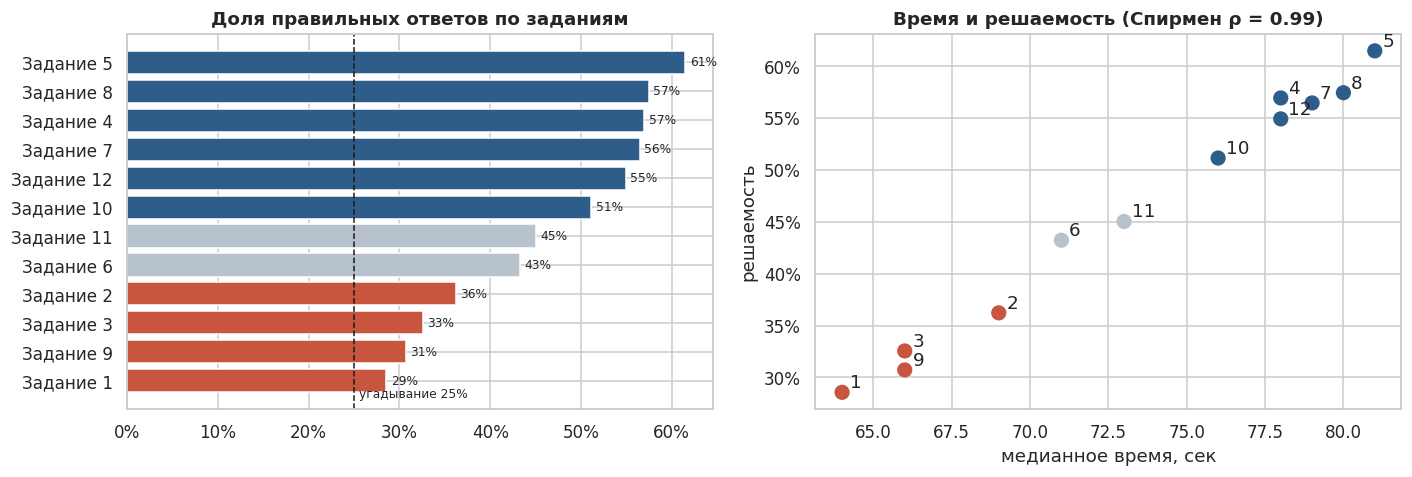

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = tasks.sort_values("решаемость_от_всех")
colors = [WARN if v < 0.4 else (GREY if v < 0.5 else ACCENT) for v in order["решаемость_от_всех"]]
axes[0].barh([f"Задание {i}" for i in order.index], order["решаемость_от_всех"], color=colors)
axes[0].axvline(0.25, ls="--", c="k", lw=1); axes[0].text(0.255, -0.6, "угадывание 25%", fontsize=8)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0].set(title="Доля правильных ответов по заданиям", xlabel="")
for y, v in enumerate(order["решаемость_от_всех"]):
    axes[0].text(v + 0.005, y, f"{v:.0%}", va="center", fontsize=8)

axes[1].scatter(tasks["медиана_времени_сек"], tasks["решаемость_от_всех"], s=80,
                c=[WARN if v < 0.4 else (GREY if v < 0.5 else ACCENT) for v in tasks["решаемость_от_всех"]])
for i, r in tasks.iterrows():
    axes[1].annotate(str(i), (r["медиана_времени_сек"], r["решаемость_от_всех"]), xytext=(5, 3), textcoords="offset points")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
rho = stats.spearmanr(tasks["медиана_времени_сек"], tasks["решаемость_от_всех"])
axes[1].set(title=f"Время и решаемость (Спирмен ρ = {rho.correlation:.2f})", xlabel="медианное время, сек", ylabel="решаемость")
plt.tight_layout(); plt.savefig(FIG / "02_tasks.png", bbox_inches="tight"); plt.show()

Неожиданный результат: **на сложные задания ученики тратят меньше времени, а не больше.** Задания 1, 9, 3 решает меньше трети участников, и сидят над ними 64–66 секунд. Над самыми лёгкими, 5 и 8, — около 80. Время на верный и неверный ответ внутри одного задания почти одинаковое.

Похоже, в сложных задачах ученики не «застревают», а сдаются и отвечают наугад. Решаемость заданий 1 и 9 — 29–31% — ненамного выше 25% случайного угадывания.

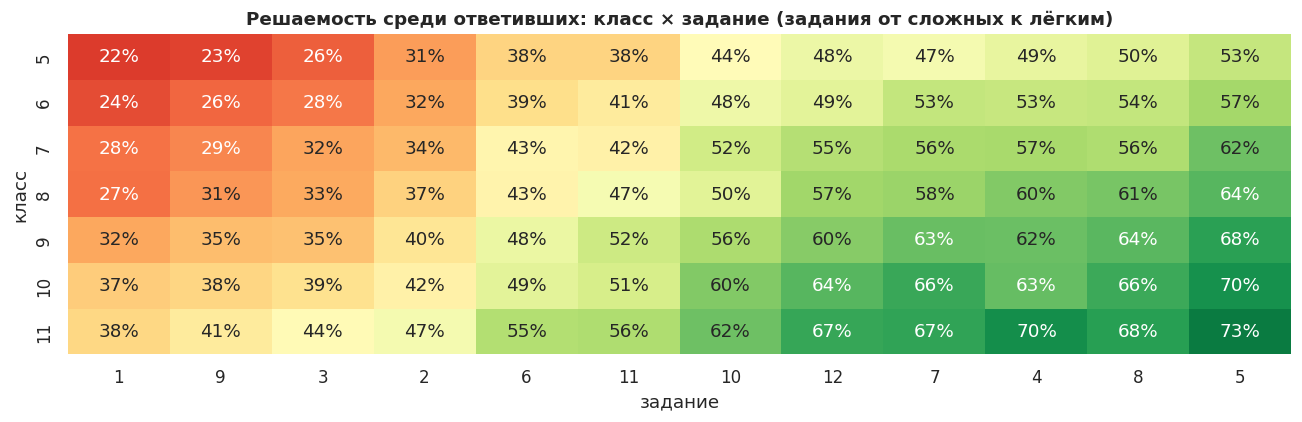

In [19]:
by_grade_task = df.groupby("grade")[COR].mean()
by_grade_task.columns = [str(i) for i in range(1, N_TASKS + 1)]
by_grade_task = by_grade_task[[str(i) for i in tasks.sort_values("решаемость_от_всех").index]]

plt.figure(figsize=(12, 4))
sns.heatmap(by_grade_task, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0.15, vmax=0.75, cbar=False)
plt.title("Решаемость среди ответивших: класс × задание (задания от сложных к лёгким)")
plt.xlabel("задание"); plt.ylabel("класс")
plt.tight_layout(); plt.savefig(FIG / "03_task_grade_heatmap.png", bbox_inches="tight"); plt.show()

Все классы решали один и тот же вариант, и все задания становятся легче с ростом класса. Но задание 1 даже одиннадцатиклассники решают в 38% случаев, а пятиклассники — в 22%, что ниже угадывания. У пятиклассников три задания (1, 3, 9) решаются на уровне 23–26%, то есть на уровне случайного выбора, ещё одно (2) — на 31%. Для младших треть олимпиады — лотерея.

### 4.1 Проверка поля с вариантом ответа
Если в задании один правильный вариант, то `answer` должен однозначно определять `correct`. Проверим.

In [20]:
rows = []
for i, (a, c) in enumerate(zip(ANS, COR), start=1):
    ct = pd.crosstab(df[a], df[c])
    chi2, p, *_ = stats.chi2_contingency(ct)
    rate = df.groupby(a)[c].mean()
    rows.append({"задание": i, "решаемость при ответе 1": rate.get(1), "2": rate.get(2), "3": rate.get(3), "4": rate.get(4),
                 "χ² p-value": p})
answer_check = pd.DataFrame(rows).set_index("задание")
answer_check.style.format("{:.1%}", subset=["решаемость при ответе 1", "2", "3", "4"]).format("{:.3f}", subset=["χ² p-value"])

,решаемость при ответе 1,2,3,4,χ² p-value
задание,,,,,
1,31.1%,29.5%,29.6%,28.9%,0.511
2,38.5%,37.2%,38.3%,37.5%,0.817
3,33.4%,34.8%,34.8%,32.6%,0.404
4,60.6%,60.0%,58.5%,58.0%,0.322
5,63.9%,64.1%,63.2%,64.3%,0.917
6,46.3%,44.3%,44.8%,45.0%,0.639
7,58.2%,57.9%,60.4%,58.5%,0.409
8,59.0%,59.3%,60.3%,60.7%,0.675
9,30.5%,33.9%,31.3%,32.3%,0.131


**Аномалия в данных.** При любом выбранном варианте доля «верно» примерно одинакова, а χ²-тест не находит связи между вариантом и правильностью в 11 заданиях из 12. Единственное исключение — задание 11 с p = 0,04; при 12 проверках такой результат ожидаем случайно (с поправкой Бонферрони порог 0,05 / 12 ≈ 0,004). Значит, один и тот же вариант (например, «3») у одних учеников засчитан, у других нет.

Возможные объяснения, которые нужно проверить с командой разработки:
1. варианты ответов перемешиваются для каждого ученика, а в лог пишется позиция на экране, а не идентификатор ответа — тогда аналитика дистракторов без ключа перемешивания невозможна;
2. поле `answer` логируется с ошибкой.

Для оценки результатов это не критично: `correct` согласован с `total_score`. Но разбор популярных неверных ответов (какой дистрактор «ловит» учеников) на этих данных сделать нельзя.

## 5. Аудитория олимпиады

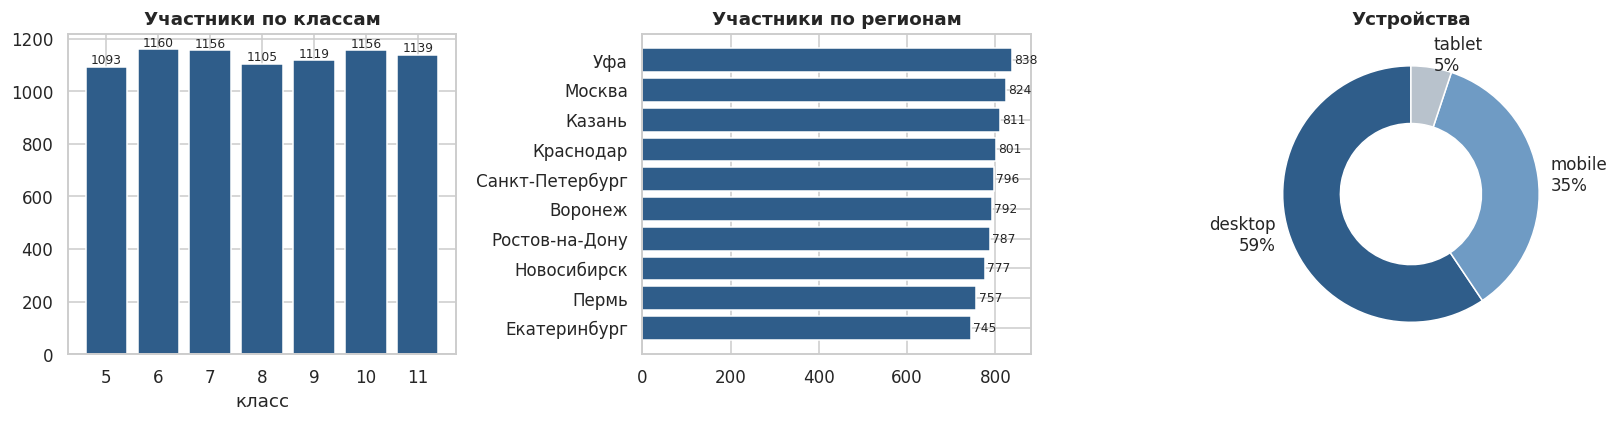

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
g = df["grade"].value_counts().sort_index()
axes[0].bar(g.index.astype(str), g.values, color=ACCENT); axes[0].set(title="Участники по классам", xlabel="класс")
for x, v in zip(g.index.astype(str), g.values): axes[0].text(x, v + 10, v, ha="center", fontsize=8)

r = df["region"].value_counts().sort_values()
axes[1].barh(r.index, r.values, color=ACCENT); axes[1].set(title="Участники по регионам")
for y, v in enumerate(r.values): axes[1].text(v + 5, y, v, va="center", fontsize=8)

d = df["device_type"].value_counts()
axes[2].pie(d.values, labels=[f"{k}\n{v / d.sum():.0%}" for k, v in d.items()], colors=[ACCENT, "#6F9BC4", GREY],
            startangle=90, wedgeprops=dict(width=0.45))
axes[2].set(title="Устройства")
plt.tight_layout(); plt.savefig(FIG / "04_audience.png", bbox_inches="tight"); plt.show()

Уникальных школ (регион + номер): 590
{'count': 590.0, 'mean': 13.4, 'std': 3.8, 'min': 4.0, '25%': 11.0, '50%': 13.0, '75%': 16.0, 'max': 29.0}


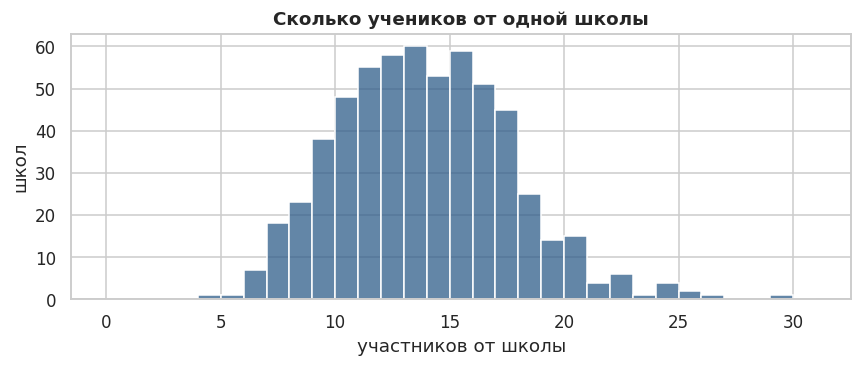

In [22]:
schools = df.groupby(["region", "school_number"]).size().rename("участников").reset_index()
print("Уникальных школ (регион + номер):", len(schools))
print(schools["участников"].describe().round(1).to_dict())
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(schools["участников"], bins=range(0, 32), color=ACCENT, ax=ax)
ax.set(title="Сколько учеников от одной школы", xlabel="участников от школы", ylabel="школ")
plt.tight_layout(); plt.savefig(FIG / "05_school_size.png", bbox_inches="tight"); plt.show()

В каждом регионе участвовали все 59 школ, от школы в среднем 13–14 учеников. Сама школа — слишком маленькая выборка, чтобы честно сравнивать их между собой (см. раздел 7).

### 5.1 Вовлечённость по классам

Данных о зарегистрировавшихся, но не пришедших ученицах и учениках в выгрузке нет, поэтому конверсию «регистрация → участие» посчитать нельзя. Вовлечённость измеряем тем, что есть:
* число участников;
* доля отвеченных заданий (полнота прохождения);
* время в олимпиаде;
* доля результатов 10–12 баллов (сильные участники).

In [23]:
eng = df.groupby("grade").agg(
    участников=("student_id", "size"),
    средний_балл=("n_correct", "mean"),
    доля_отвеченных=("n_answered", lambda s: s.mean() / N_TASKS),
    прошли_все_12=("n_skipped", lambda s: (s == 0).mean()),
    минут_в_олимпиаде=("duration_min", "mean"),
    сек_на_задание=("avg_time_per_task", "mean"),
    доля_10_12_баллов=("n_correct", lambda s: (s >= 10).mean()),
)
eng.style.format({"средний_балл": "{:.2f}", "доля_отвеченных": "{:.1%}", "прошли_все_12": "{:.1%}",
                  "минут_в_олимпиаде": "{:.1f}", "сек_на_задание": "{:.1f}", "доля_10_12_баллов": "{:.1%}"})

,участников,средний_балл,доля_отвеченных,прошли_все_12,минут_в_олимпиаде,сек_на_задание,доля_10_12_баллов
grade,,,,,,,
5,1093,4.50,96.0%,61.9%,14.1,73.6,4.5%
6,1160,4.85,96.1%,62.0%,14.1,73.5,4.3%
7,1156,5.26,96.0%,60.8%,14.1,73.5,6.2%
8,1105,5.46,96.0%,61.4%,14.1,73.5,6.8%
9,1119,5.91,95.9%,60.0%,14.1,73.4,10.4%
10,1156,6.21,96.0%,61.0%,14.1,73.6,13.1%
11,1139,6.62,96.3%,63.7%,14.1,73.4,16.8%


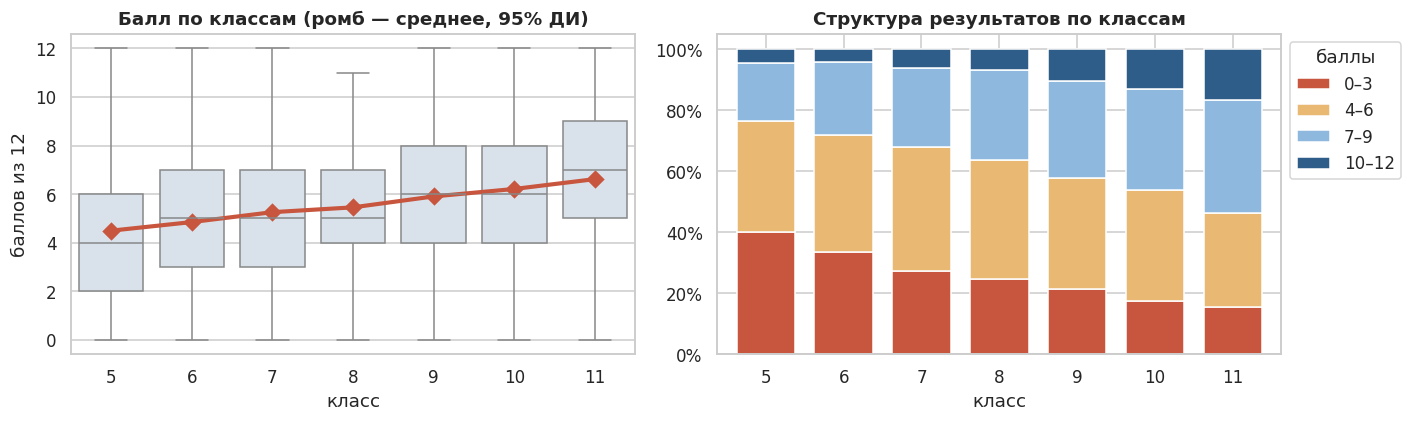

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="grade", y="n_correct", color="#D6E2EE", ax=axes[0], showfliers=False)
sns.pointplot(data=df, x="grade", y="n_correct", color=WARN, ax=axes[0], errorbar=("ci", 95), markers="D")
axes[0].set(title="Балл по классам (ромб — среднее, 95% ДИ)", xlabel="класс", ylabel="баллов из 12")

share = pd.crosstab(df["grade"], df["score_band"], normalize="index")
share.plot(kind="bar", stacked=True, ax=axes[1], color=["#C8553D", "#E9B872", "#8FB8DE", "#2F5D8A"], width=0.75)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].set(title="Структура результатов по классам", xlabel="класс", ylabel="")
axes[1].legend(title="баллы", bbox_to_anchor=(1, 1)); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(FIG / "06_grade_scores.png", bbox_inches="tight"); plt.show()

Участники распределены по классам ровно (1 090–1 160 на класс), полнота прохождения одинаковая — около 96% отвеченных заданий, время тоже одинаковое, ~14 минут. Все 12 заданий без пропусков прошли 60–64% учеников в каждом классе. По поведению классы не различаются.

Различается результат: средний балл растёт с 4,5 в 5-м классе до 6,6 в 11-м, а доля сильных результатов (10–12 баллов) — в разы. Задания не адаптированы под возраст — отсюда и разрыв.

### 5.2 Сводные таблицы и многоуровневые группировки

In [25]:
pivot_n = pd.pivot_table(df, index="region", columns="grade", values="student_id", aggfunc="count", margins=True, margins_name="Итого")
pivot_n

grade,5,6,7,8,9,10,11,Итого
region,,,,,,,,
Воронеж,112,125,110,125,126,91,103,792
Екатеринбург,91,102,108,107,115,118,104,745
Казань,122,127,114,107,114,118,109,811
Краснодар,109,120,104,101,105,139,123,801
Москва,128,110,122,115,134,107,108,824
Новосибирск,99,113,102,108,116,120,119,777
Пермь,114,106,127,92,97,99,122,757
Ростов-на-Дону,98,98,131,132,99,114,115,787
Санкт-Петербург,95,138,110,118,101,126,108,796


In [26]:
pivot_score = pd.pivot_table(df, index="region", columns="stage", values="n_correct", aggfunc="mean", margins=True, margins_name="Все")
pivot_score.round(2).style.background_gradient(cmap="RdYlGn", axis=None, vmin=4.3, vmax=6.8).format("{:.2f}")

stage,5–6 кл.,7–9 кл.,10–11 кл.,Все
region,,,,
Воронеж,4.62,5.60,6.41,5.50
Екатеринбург,5.01,5.47,6.38,5.62
Казань,4.51,5.51,6.51,5.48
Краснодар,4.53,5.43,6.23,5.43
Москва,4.86,5.71,6.45,5.66
Новосибирск,4.88,5.69,6.55,5.73
Пермь,4.71,5.27,6.19,5.38
Ростов-на-Дону,4.46,5.52,6.69,5.60
Санкт-Петербург,4.68,5.67,6.36,5.58


In [27]:
multi = (df.groupby(["timezone", "region", "device_type"], observed=True)
           .agg(участников=("student_id", "size"), балл=("n_correct", "mean"),
                разрывы=("has_disconnect", "mean"), пропуски=("n_skipped", "mean"))
           .round(2))
multi.head(12)

участников  балл  разрывы  пропуски
timezone region    device_type                                     
МСК      Воронеж   desktop             450  5.51     0.15      0.43
                   mobile              293  5.51     0.19      0.49
                   tablet               49  5.43     0.31      0.45
         Казань    desktop             475  5.45     0.16      0.55
                   mobile              295  5.47     0.15      0.46
                   tablet               41  5.95     0.12      0.44
         Краснодар desktop             460  5.57     0.16      0.48
                   mobile              308  5.22      0.2      0.48
                   tablet               33  5.48     0.24      0.55
         Москва    desktop             471  5.66     0.19      0.52
                   mobile              305  5.64     0.19      0.51
                   tablet               48  5.77      0.1      0.54

## 6. Региональные мини-отчёты

Функция `region_report()` собирает для выбранного региона:
* ключевые метрики и их отклонение от среднего по всей олимпиаде;
* активность: участники по классам и устройствам, время старта;
* результаты: распределение баллов, решаемость заданий против общей;
* топ-школ с фильтром по минимальному числу участников и доверительными интервалами.

`region_pdf()` сохраняет то же самое в PDF на две страницы.

In [28]:
OVERALL = {
    "участников": len(df) / df["region"].nunique(),
    "средний_балл": df["n_correct"].mean(),
    "доля_отвеченных": df["n_answered"].mean() / N_TASKS,
    "минут": df["duration_min"].mean(),
    "с_разрывами": df["has_disconnect"].mean(),
    "с_мобильных": (df["device_type"] != "desktop").mean(),
}
TASK_OVERALL = df[COR].fillna(0).mean().values


def mean_ci(s, level=0.95):
    s = s.astype(float)
    m, se = s.mean(), s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else np.nan
    h = se * stats.t.ppf((1 + level) / 2, len(s) - 1) if len(s) > 1 else np.nan
    return m, m - h, m + h


def region_summary(data, region, min_students=10, top_n=5):
    r = data[data["region"] == region]
    kpi = {
        "участников": len(r),
        "школ": r["school_number"].nunique(),
        "средний_балл": r["n_correct"].mean(),
        "медиана_балла": r["n_correct"].median(),
        "доля_отвеченных": r["n_answered"].mean() / N_TASKS,
        "минут": r["duration_min"].mean(),
        "с_разрывами": r["has_disconnect"].mean(),
        "с_мобильных": (r["device_type"] != "desktop").mean(),
        "часовой_пояс": TZ[region],
    }
    # сравнение с остальными регионами: Манна–Уитни
    other = data.loc[data["region"] != region, "n_correct"]
    kpi["p_value_vs_остальные"] = stats.mannwhitneyu(r["n_correct"], other).pvalue

    sch = r.groupby("school_number")["n_correct"].agg(["size", "mean", "std"])
    sch = sch[sch["size"] >= min_students].copy()
    ci = sch.apply(lambda x: x["std"] / np.sqrt(x["size"]) * stats.t.ppf(0.975, x["size"] - 1), axis=1)
    sch["ci_low"], sch["ci_high"] = sch["mean"] - ci, sch["mean"] + ci
    sch = sch.sort_values("mean", ascending=False).head(top_n).rename(
        columns={"size": "участников", "mean": "средний_балл"}).drop(columns="std")
    sch.index.name = "школа №"

    by_grade = r.groupby("grade").agg(участников=("student_id", "size"), средний_балл=("n_correct", "mean"))
    return r, kpi, sch, by_grade


def region_text(region, kpi):
    diff = kpi["средний_балл"] - OVERALL["средний_балл"]
    sign = "выше" if diff > 0 else "ниже"
    signif = ("разница статистически значима" if kpi["p_value_vs_остальные"] < 0.05
              else "разница в пределах случайного разброса")
    return (f"{region} ({kpi['часовой_пояс']}): {kpi['участников']} участников из {kpi['школ']} школ. "
            f"Средний балл {kpi['средний_балл']:.2f} из 12 — на {abs(diff):.2f} {sign} среднего по олимпиаде, "
            f"{signif} (Манна–Уитни p = {kpi['p_value_vs_остальные']:.2f}). "
            f"Ответили на {kpi['доля_отвеченных']:.0%} заданий, провели в олимпиаде {kpi['минут']:.1f} мин; "
            f"разрывы связи были у {kpi['с_разрывами']:.0%}, с телефона или планшета — {kpi['с_мобильных']:.0%}.")


def region_figure(data, region, r, kpi, sch, by_grade):
    fig = plt.figure(figsize=(14, 8.5))
    gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.42)
    fig.suptitle(f"Регион: {region}", fontsize=16, fontweight="bold", x=0.02, ha="left", y=0.99)

    ax = fig.add_subplot(gs[0, 0])
    ax.bar(by_grade.index.astype(str), by_grade["участников"], color=ACCENT)
    ax.set(title="Участники по классам", xlabel="класс")

    ax = fig.add_subplot(gs[0, 1])
    all_g = data.groupby("grade")["n_correct"].mean()
    ax.plot(all_g.index, all_g.values, "o--", color=GREY, label="все регионы")
    ax.plot(by_grade.index, by_grade["средний_балл"], "o-", color=ACCENT, label=region)
    ax.set(title="Средний балл по классам", xlabel="класс", ylim=(3, 8)); ax.set_xticks(range(5, 12)); ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[0, 2])
    h = r["n_correct"].value_counts(normalize=True).reindex(range(13), fill_value=0)
    ha = data["n_correct"].value_counts(normalize=True).reindex(range(13), fill_value=0)
    ax.bar(h.index, h.values, color=ACCENT, alpha=0.85, label=region)
    ax.step(ha.index, ha.values, where="mid", color=WARN, label="все регионы")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set(title="Распределение баллов", xlabel="баллов"); ax.legend(fontsize=8)

    ax = fig.add_subplot(gs[1, 0:2])
    rt = r[COR].fillna(0).mean().values
    delta = rt - TASK_OVERALL
    ax.bar(range(1, 13), rt, color=[ACCENT if d >= 0 else WARN for d in delta])
    ax.plot(range(1, 13), TASK_OVERALL, "k_", ms=22, mew=2, label="среднее по олимпиаде")
    ax.set_xticks(range(1, 13)); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set(title="Решаемость заданий (красный — ниже общего уровня)", xlabel="задание", ylim=(0, 0.8)); ax.legend(fontsize=8, loc="upper left")

    ax = fig.add_subplot(gs[1, 2])
    if len(sch):
        y = np.arange(len(sch))[::-1]
        ax.errorbar(sch["средний_балл"], y, xerr=[sch["средний_балл"] - sch["ci_low"], sch["ci_high"] - sch["средний_балл"]],
                    fmt="o", color=ACCENT, ecolor=GREY, capsize=3)
        ax.axvline(kpi["средний_балл"], ls="--", c=WARN, lw=1)
        ax.set_yticks(y); ax.set_yticklabels([f"№{i} (n={n})" for i, n in zip(sch.index, sch["участников"])])
    ax.set_title("Топ-школы: балл и 95% ДИ", loc="right"); ax.set_xlabel("баллов")
    return fig


def region_report(data, region, show=True, save_png=False):
    """Мини-отчёт по одному региону: текст, таблицы, графики."""
    r, kpi, sch, by_grade = region_summary(data, region)
    fig = region_figure(data, region, r, kpi, sch, by_grade)
    if save_png:
        fig.savefig(FIG / f"region_{region}.png", bbox_inches="tight")
    if show:
        print(region_text(region, kpi))
        display(sch.round(2))
        plt.show()
    else:
        plt.close(fig)
    return kpi, sch

Москва (МСК): 824 участников из 59 школ. Средний балл 5.66 из 12 — на 0.11 выше среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.22). Ответили на 96% заданий, провели в олимпиаде 14.1 мин; разрывы связи были у 19%, с телефона или планшета — 43%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
26,10,7.50,5.65,9.35
4,14,7.36,5.67,9.05
43,12,6.83,5.48,8.18
34,19,6.79,5.49,8.09
28,16,6.75,5.22,8.28


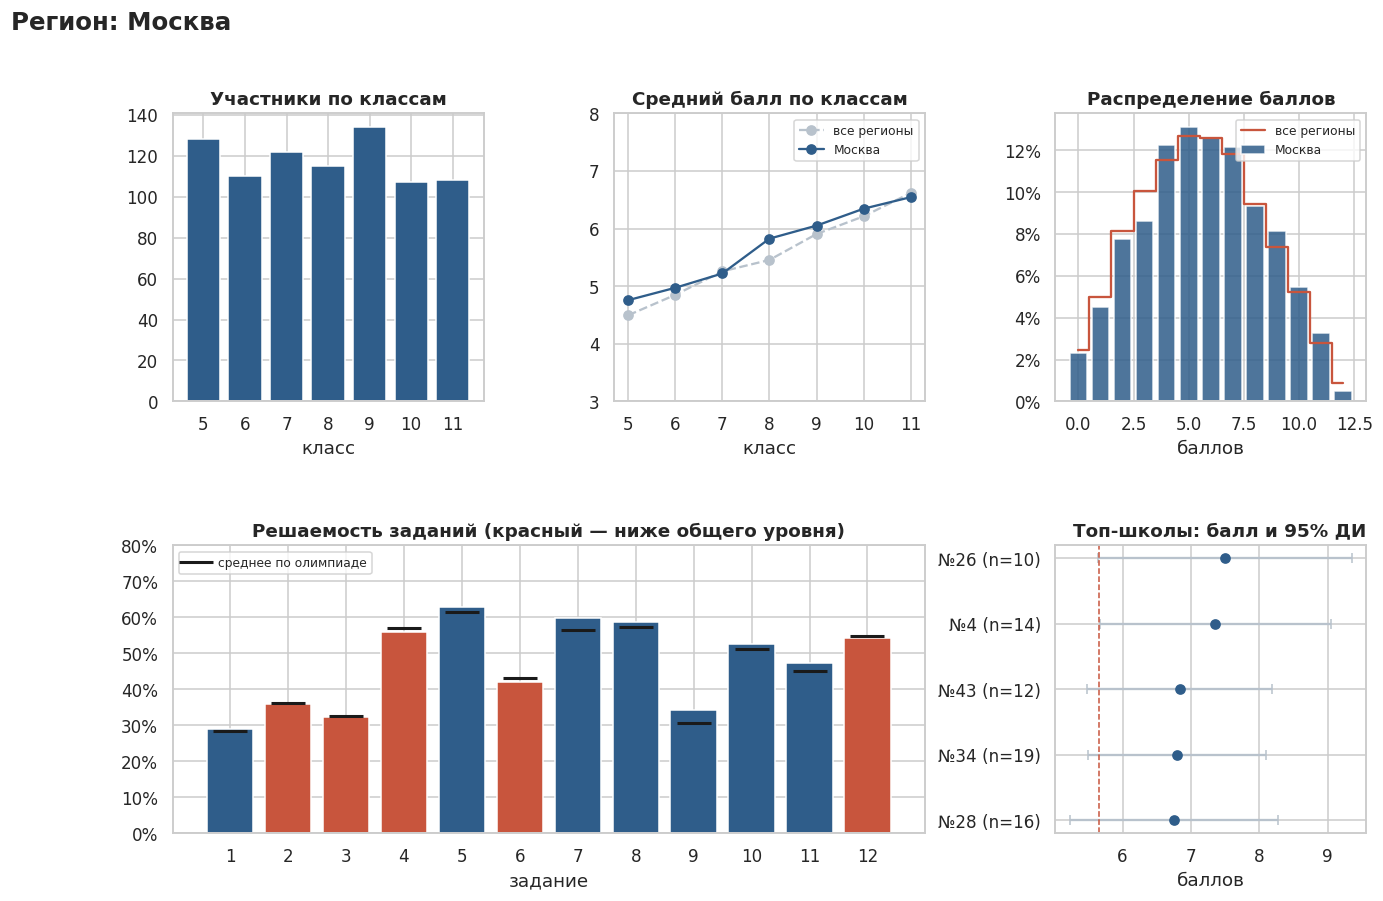

In [29]:
_ = region_report(df, "Москва", save_png=True)

Отчёт по любому другому региону — одна строка: `region_report(df, "Уфа")`. Ниже — сводная таблица по всем десяти регионам и отчёты подряд.

In [30]:
kpis = {}
for reg in sorted(df["region"].unique()):
    k, _ = region_report(df, reg, show=False, save_png=True)
    kpis[reg] = k
reg_table = pd.DataFrame(kpis).T.sort_values("средний_балл", ascending=False)
reg_table.style.format({"средний_балл": "{:.2f}", "медиана_балла": "{:.0f}", "доля_отвеченных": "{:.1%}", "минут": "{:.1f}",
                        "с_разрывами": "{:.1%}", "с_мобильных": "{:.1%}", "p_value_vs_остальные": "{:.2f}"})

,участников,школ,средний_балл,медиана_балла,доля_отвеченных,минут,с_разрывами,с_мобильных,часовой_пояс,p_value_vs_остальные
Новосибирск,777,59,5.73,6,96.0%,14.2,17.2%,39.5%,МСК+4,0.08
Москва,824,59,5.66,6,95.7%,14.1,18.8%,42.8%,МСК,0.22
Екатеринбург,745,59,5.62,6,96.1%,14.1,17.9%,39.1%,МСК+2,0.48
Ростов-на-Дону,787,59,5.60,6,96.1%,14.2,18.4%,39.5%,МСК,0.46
Санкт-Петербург,796,59,5.58,6,96.5%,14.1,18.1%,41.7%,МСК,0.86
Воронеж,792,59,5.50,6,96.2%,14.1,17.4%,43.2%,МСК,0.70
Уфа,838,59,5.49,5,96.2%,14.1,15.9%,38.1%,МСК+2,0.48
Казань,811,59,5.48,5,95.7%,14.1,15.5%,41.4%,МСК,0.46
Краснодар,801,59,5.43,5,96.0%,14.1,17.9%,42.6%,МСК,0.32
Пермь,757,59,5.38,5,96.1%,14.1,17.8%,37.8%,МСК+2,0.08



Воронеж (МСК): 792 участников из 59 школ. Средний балл 5.50 из 12 — на 0.04 ниже среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.70). Ответили на 96% заданий, провели в олимпиаде 14.1 мин; разрывы связи были у 17%, с телефона или планшета — 43%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
46,10,7.10,4.83,9.37
53,12,6.67,5.22,8.11
40,17,6.59,5.26,7.91
27,12,6.50,4.46,8.54
32,17,6.47,4.78,8.16


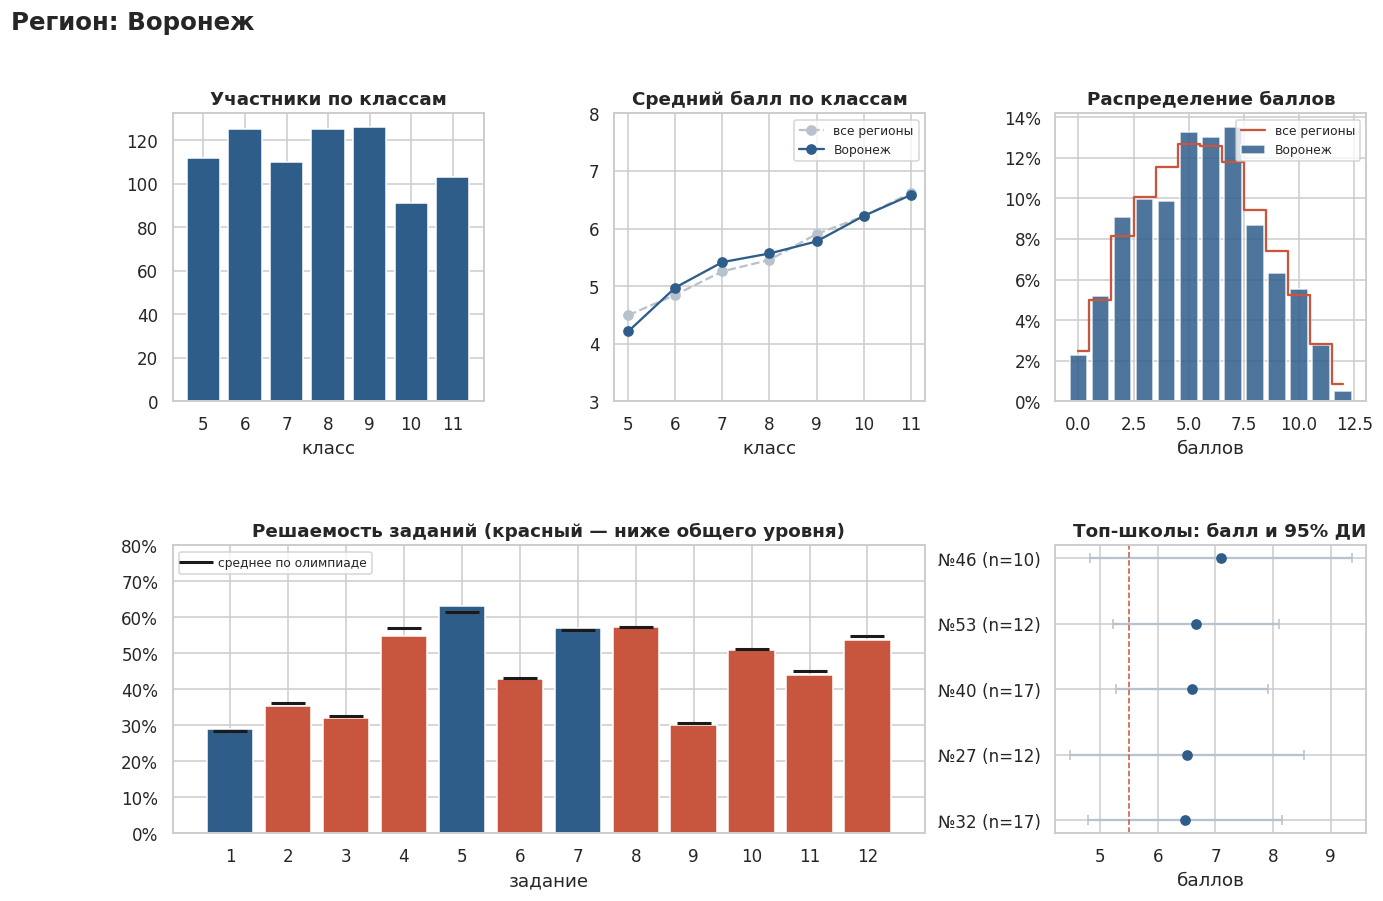


Екатеринбург (МСК+2): 745 участников из 59 школ. Средний балл 5.62 из 12 — на 0.07 выше среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.48). Ответили на 96% заданий, провели в олимпиаде 14.1 мин; разрывы связи были у 18%, с телефона или планшета — 39%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
22,10,7.10,5.43,8.77
35,11,7.09,5.23,8.95
47,18,6.61,5.30,7.92
31,16,6.56,4.96,8.17
26,10,6.50,4.26,8.74


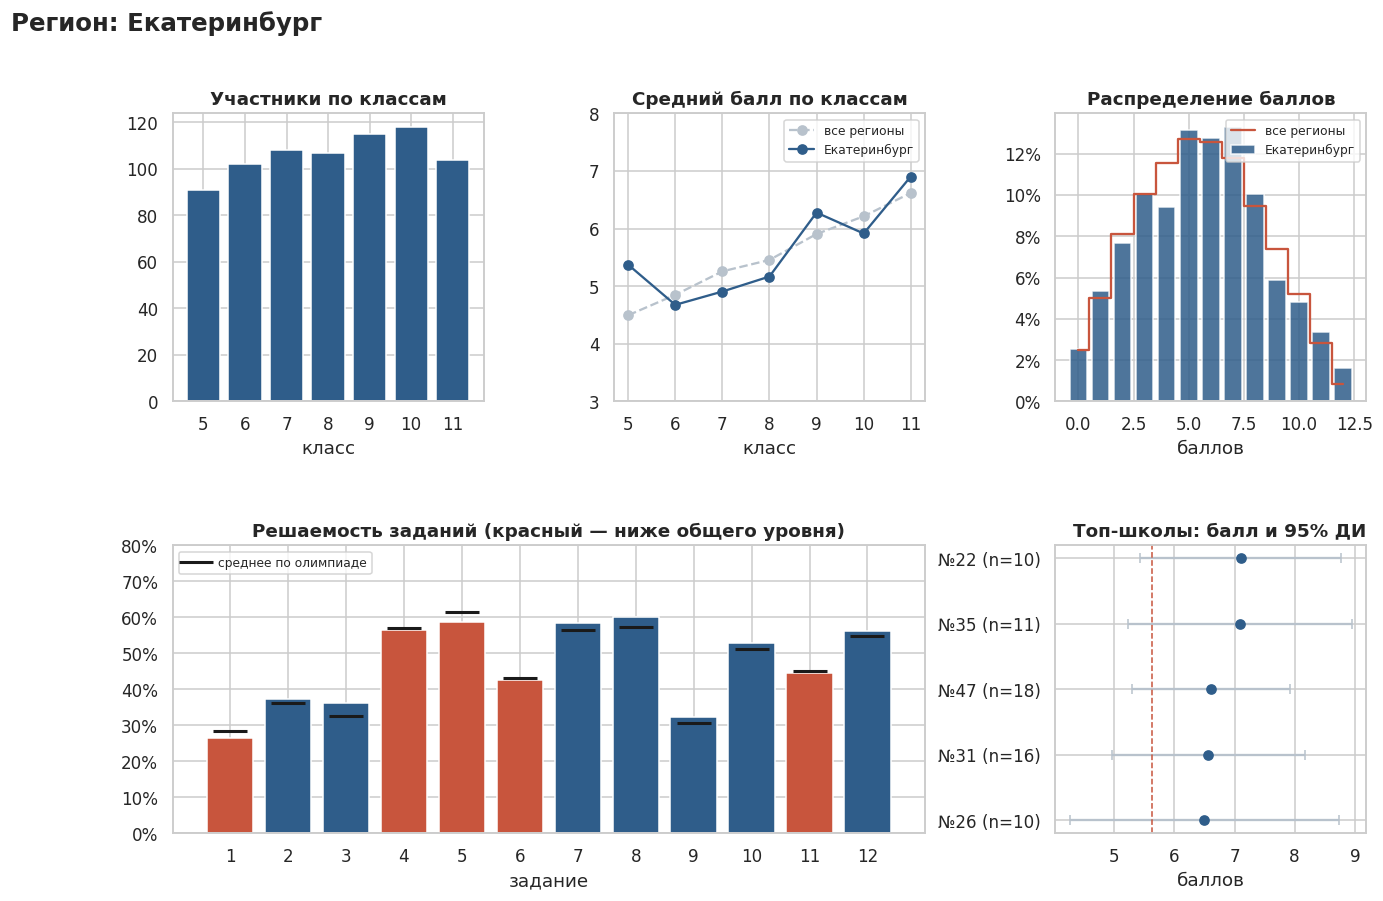

Казань (МСК): 811 участников из 59 школ. Средний балл 5.48 из 12 — на 0.06 ниже среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.46). Ответили на 96% заданий, провели в олимпиаде 14.1 мин; разрывы связи были у 16%, с телефона или планшета — 41%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
5,21,7.29,6.05,8.53
24,12,6.92,4.86,8.97
11,10,6.80,4.44,9.16
30,13,6.77,4.97,8.57
9,15,6.73,4.81,8.66


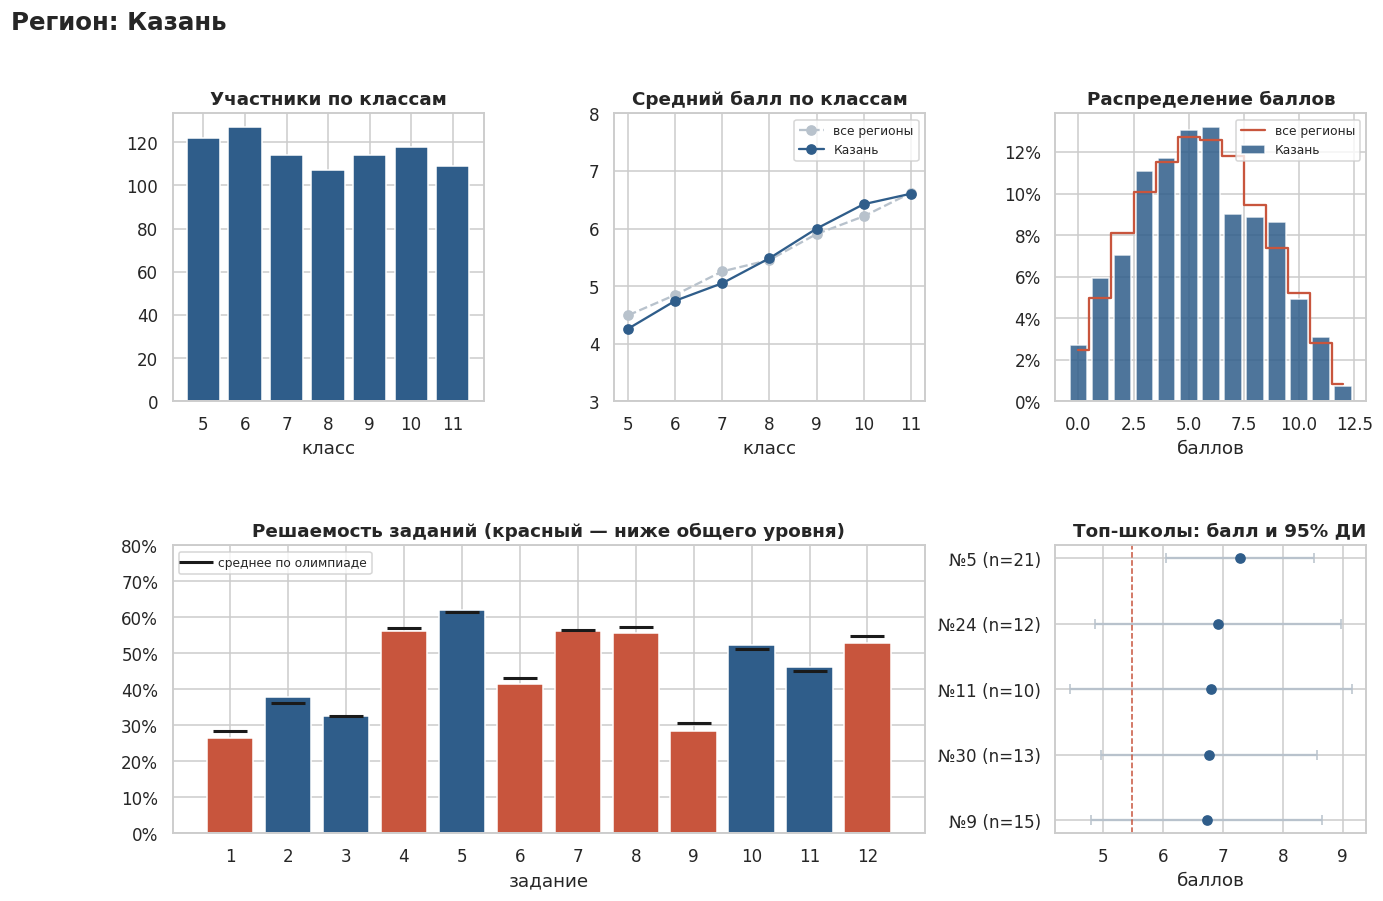


Краснодар (МСК): 801 участников из 59 школ. Средний балл 5.43 из 12 — на 0.12 ниже среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.32). Ответили на 96% заданий, провели в олимпиаде 14.1 мин; разрывы связи были у 18%, с телефона или планшета — 43%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
53,12,7.17,5.20,9.14
13,18,6.83,5.30,8.37
6,17,6.76,5.52,8.00
12,13,6.54,5.15,7.93
49,15,6.47,4.36,8.57


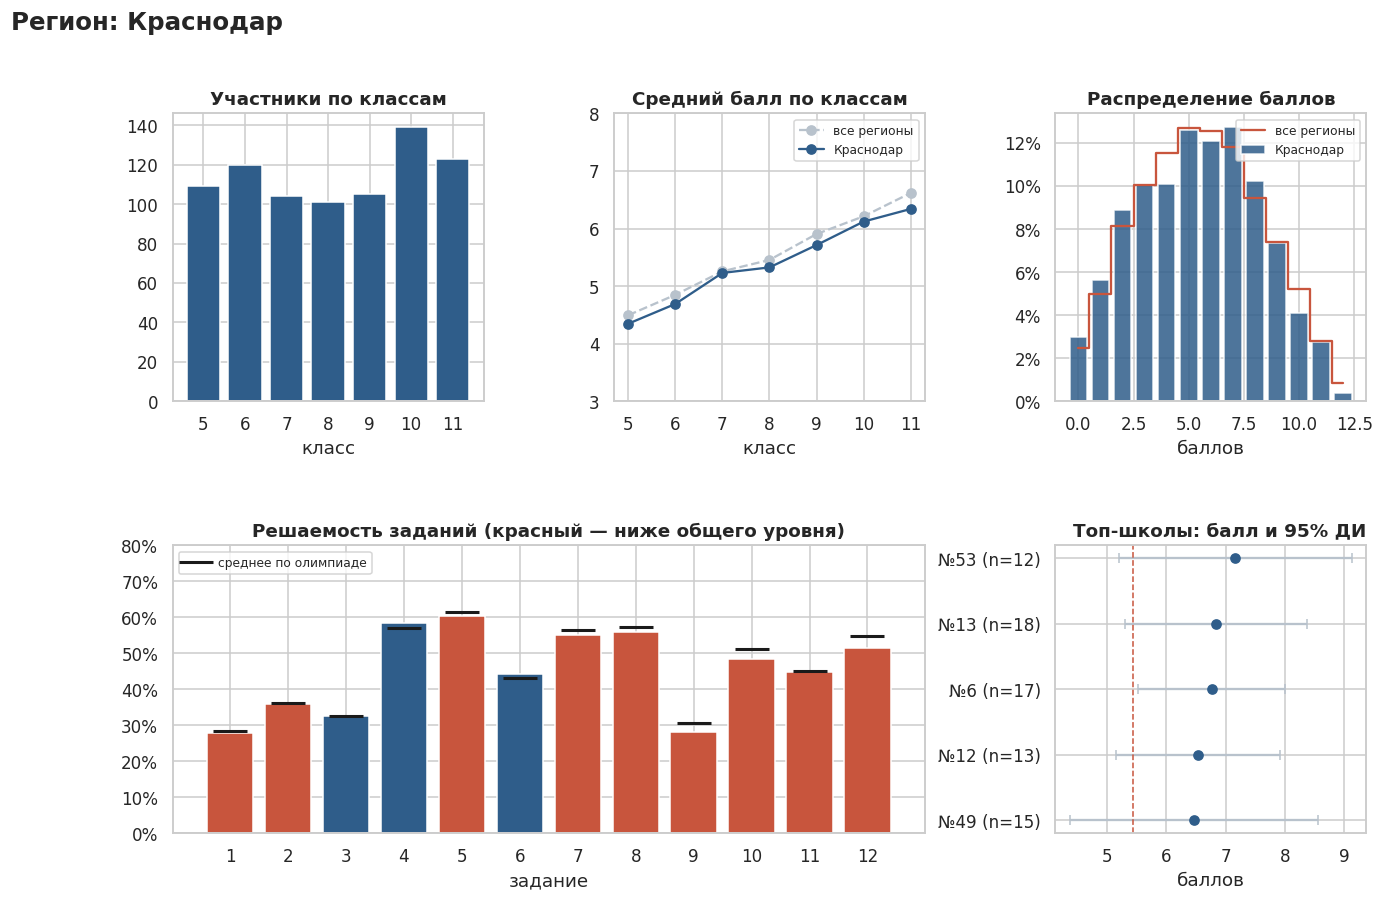


Москва (МСК): 824 участников из 59 школ. Средний балл 5.66 из 12 — на 0.11 выше среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.22). Ответили на 96% заданий, провели в олимпиаде 14.1 мин; разрывы связи были у 19%, с телефона или планшета — 43%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
26,10,7.50,5.65,9.35
4,14,7.36,5.67,9.05
43,12,6.83,5.48,8.18
34,19,6.79,5.49,8.09
28,16,6.75,5.22,8.28


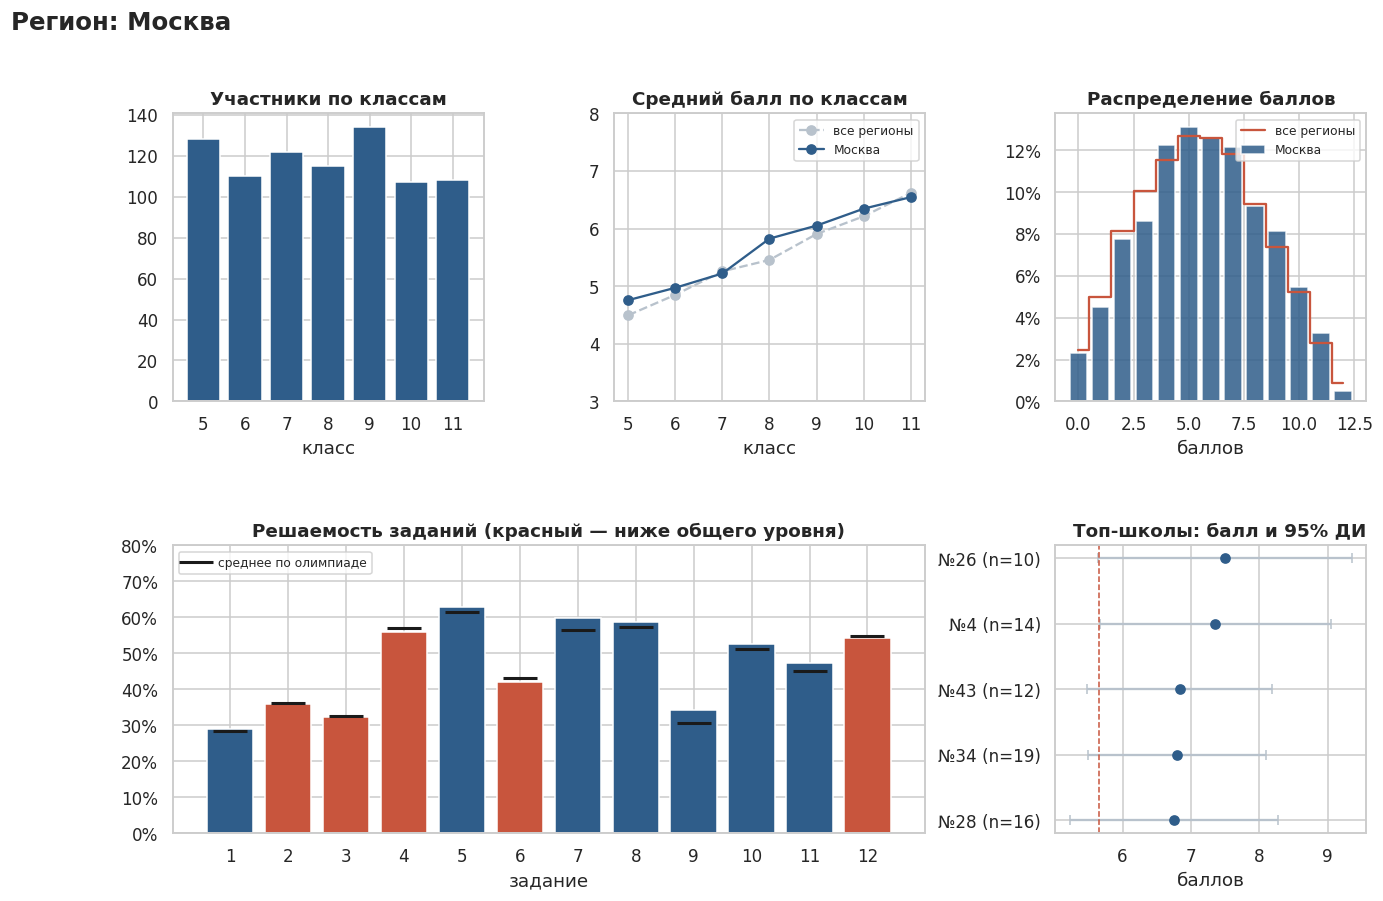


Новосибирск (МСК+4): 777 участников из 59 школ. Средний балл 5.73 из 12 — на 0.19 выше среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.08). Ответили на 96% заданий, провели в олимпиаде 14.2 мин; разрывы связи были у 17%, с телефона или планшета — 40%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
52,10,7.50,5.61,9.39
6,12,7.25,5.43,9.07
57,12,7.17,5.99,8.34
39,17,7.12,5.44,8.79
49,12,6.67,4.84,8.49


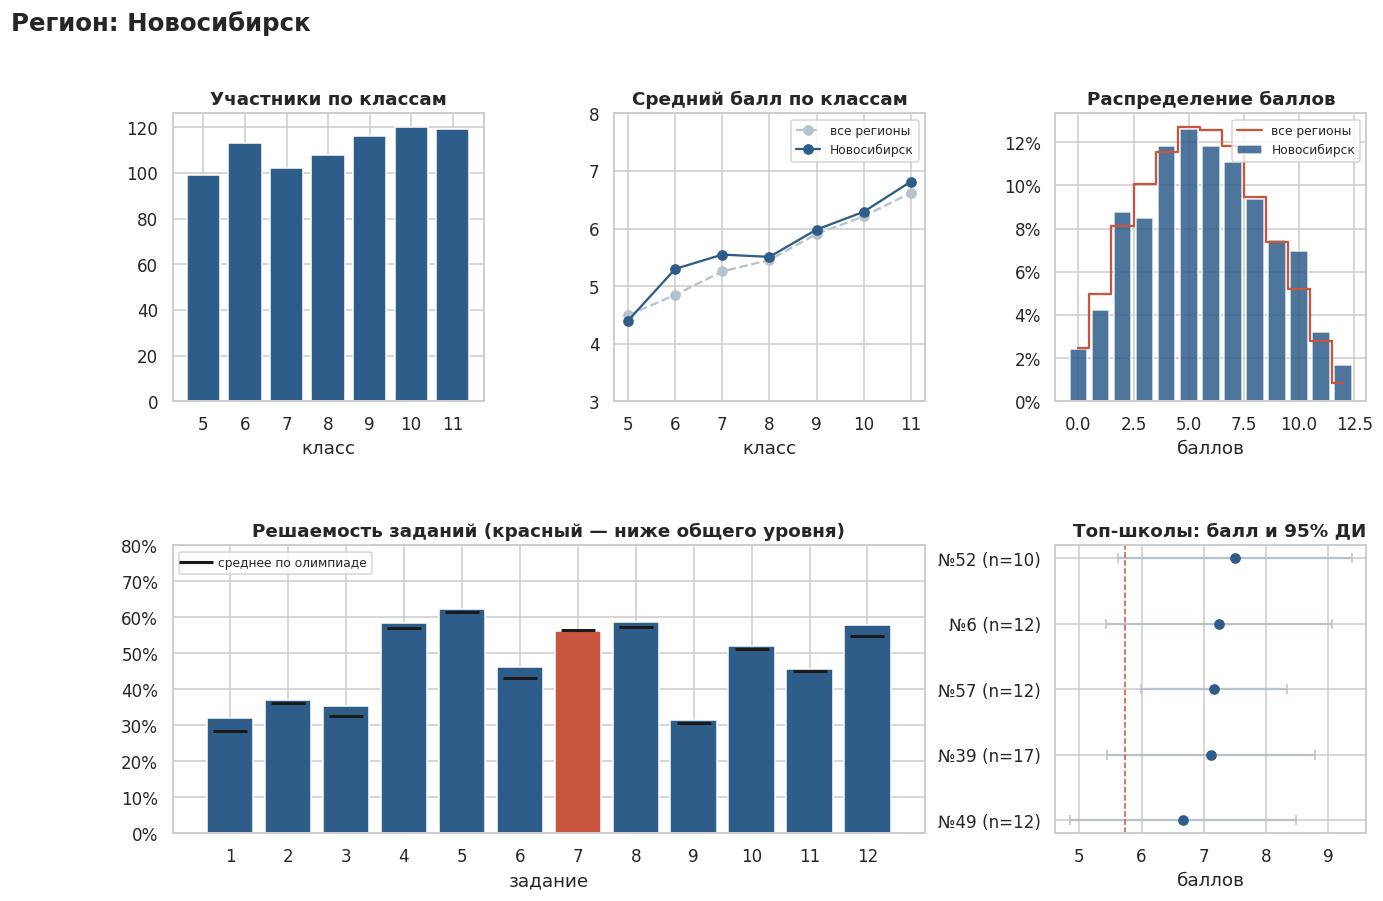

Пермь (МСК+2): 757 участников из 59 школ. Средний балл 5.38 из 12 — на 0.17 ниже среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.08). Ответили на 96% заданий, провели в олимпиаде 14.1 мин; разрывы связи были у 18%, с телефона или планшета — 38%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
48,14,7.29,5.69,8.88
28,11,6.91,5.05,8.77
37,10,6.70,4.49,8.91
49,12,6.67,4.92,8.41
34,17,6.41,5.15,7.67


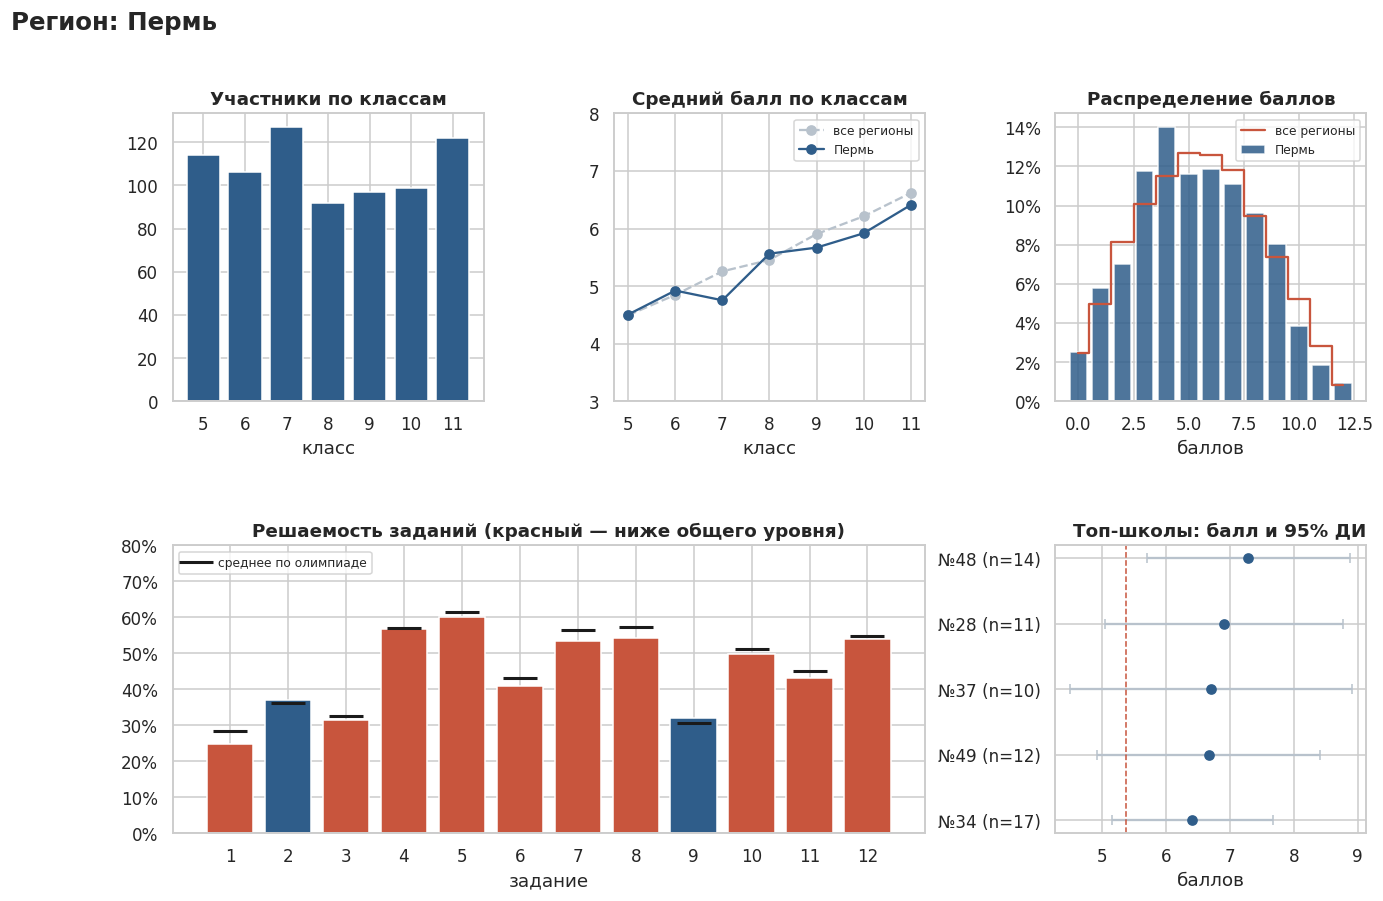


Ростов-на-Дону (МСК): 787 участников из 59 школ. Средний балл 5.60 из 12 — на 0.05 выше среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.46). Ответили на 96% заданий, провели в олимпиаде 14.2 мин; разрывы связи были у 18%, с телефона или планшета — 40%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
13,20,7.95,6.88,9.02
4,13,7.77,5.89,9.65
45,14,7.14,5.41,8.88
37,15,6.73,5.54,7.93
22,15,6.60,5.35,7.85


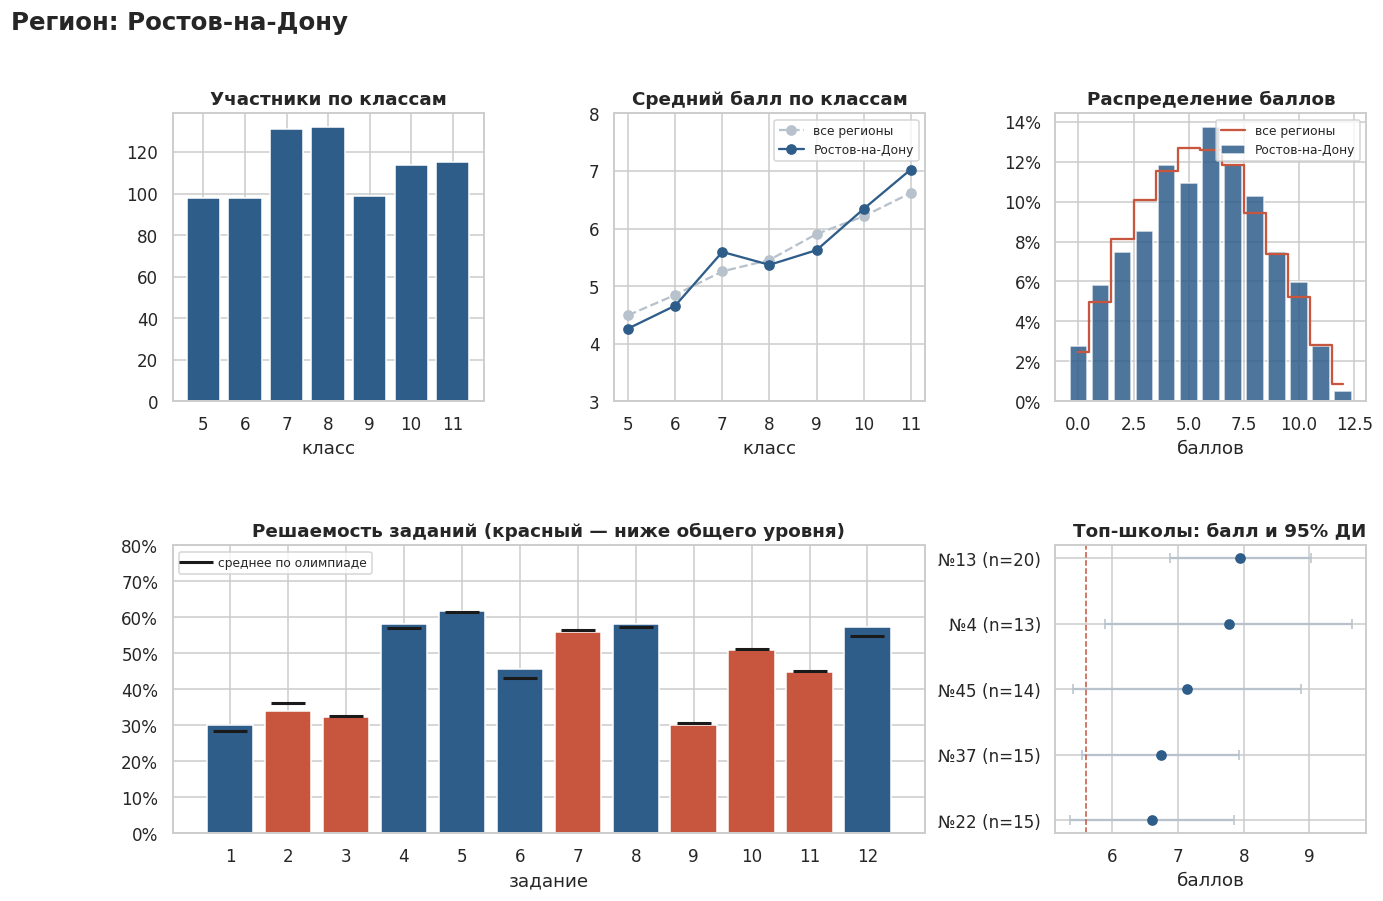


Санкт-Петербург (МСК): 796 участников из 59 школ. Средний балл 5.58 из 12 — на 0.03 выше среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.86). Ответили на 96% заданий, провели в олимпиаде 14.1 мин; разрывы связи были у 18%, с телефона или планшета — 42%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
11,12,7.92,6.60,9.23
56,10,7.40,5.34,9.46
40,21,7.19,5.84,8.55
13,11,6.73,4.73,8.72
51,12,6.67,5.22,8.11


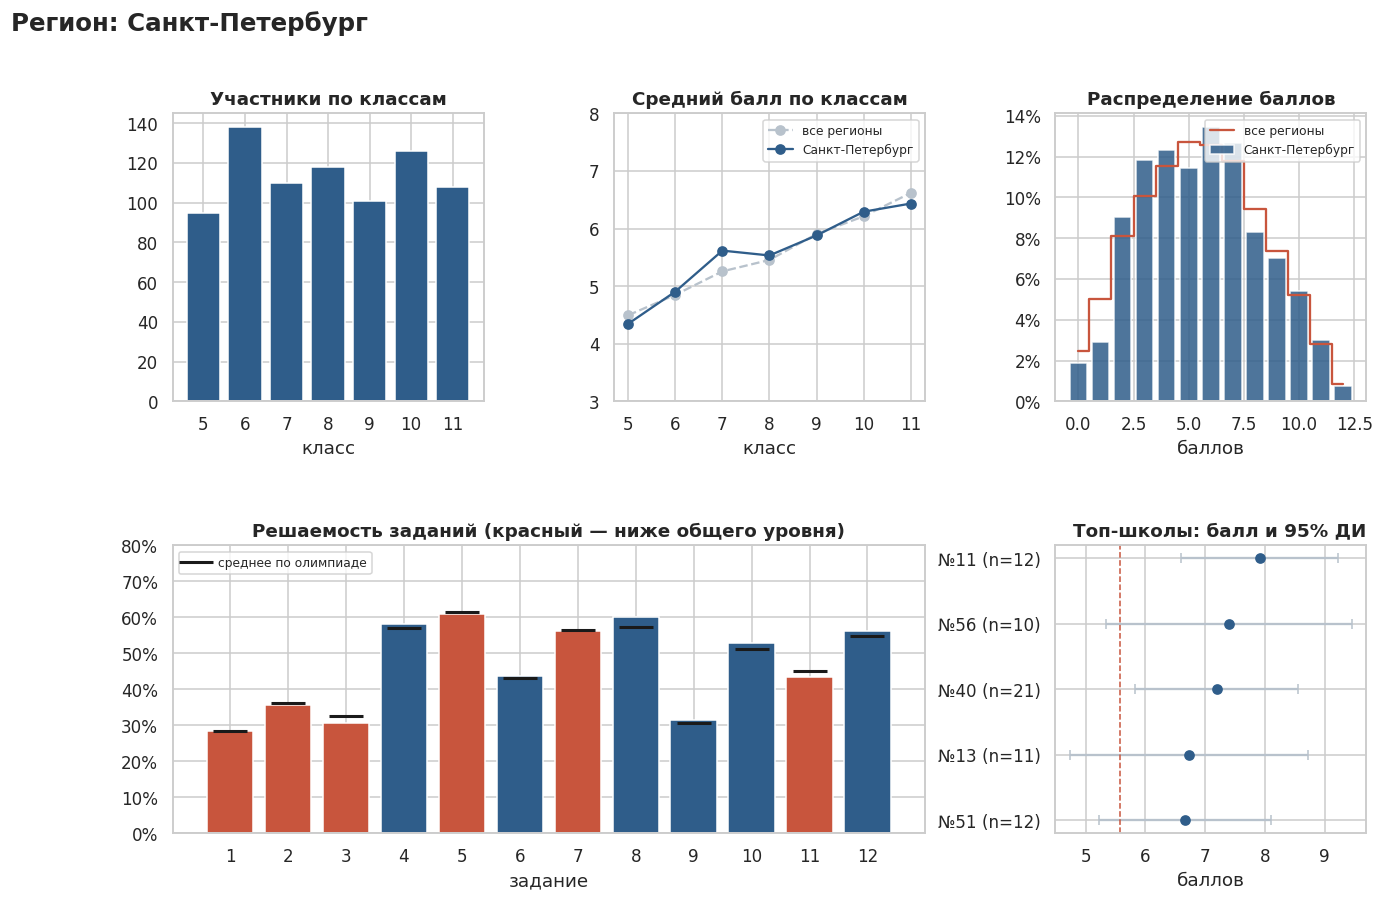


Уфа (МСК+2): 838 участников из 59 школ. Средний балл 5.49 из 12 — на 0.06 ниже среднего по олимпиаде, разница в пределах случайного разброса (Манна–Уитни p = 0.48). Ответили на 96% заданий, провели в олимпиаде 14.1 мин; разрывы связи были у 16%, с телефона или планшета — 38%.


,участников,средний_балл,ci_low,ci_high
школа №,,,,
57,11,7.00,5.15,8.85
52,15,6.87,5.13,8.60
53,16,6.56,4.83,8.29
32,15,6.53,5.43,7.64
29,12,6.50,4.82,8.18


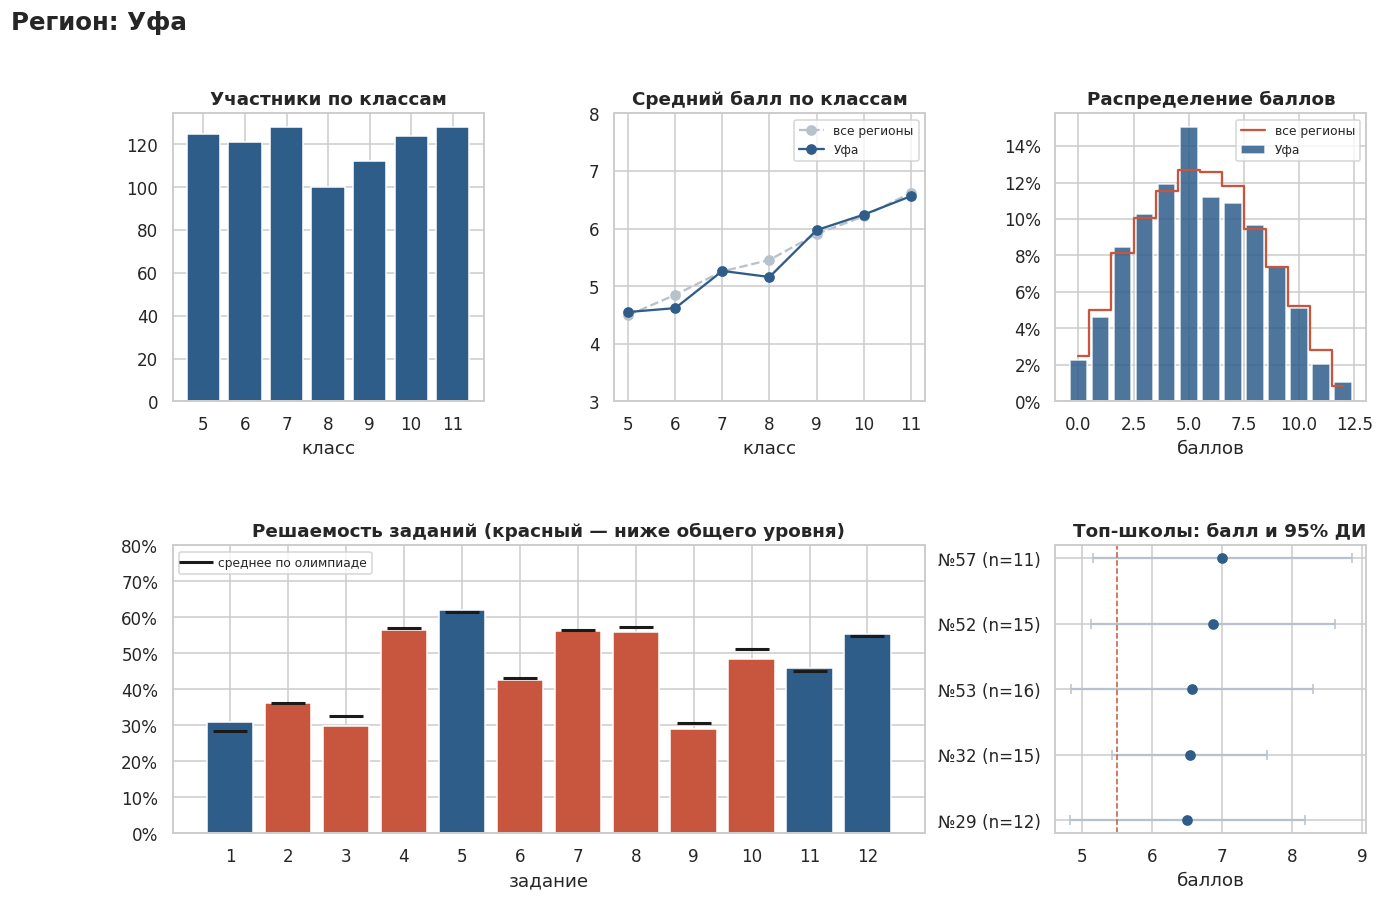

In [31]:
for reg in sorted(df["region"].unique()):
    print("\n" + "=" * 110)
    _ = region_report(df, reg)

### 6.1 Автоматическая генерация PDF-отчётов

In [32]:
def region_pdf(data, region, folder=REP):
    r, kpi, sch, by_grade = region_summary(data, region)
    path = folder / f"report_{region}.pdf"
    with PdfPages(path) as pdf:
        # стр. 1 — текстовая сводка
        fig = plt.figure(figsize=(11.7, 8.3))
        fig.text(0.05, 0.92, f"Олимпиада 2026 · мини-отчёт · {region}", fontsize=20, fontweight="bold")
        fig.text(0.05, 0.86, "Данные после очистки: без дубликатов и сверхбыстрых сессий", fontsize=10, color="grey")
        cards = [("Участников", f"{kpi['участников']}"), ("Школ", f"{kpi['школ']}"),
                 ("Средний балл", f"{kpi['средний_балл']:.2f} / 12"), ("Отвечено заданий", f"{kpi['доля_отвеченных']:.0%}"),
                 ("Разрывы связи", f"{kpi['с_разрывами']:.0%}"), ("Мобильные", f"{kpi['с_мобильных']:.0%}")]
        for i, (lab, val) in enumerate(cards):
            x = 0.05 + (i % 3) * 0.31; y = 0.70 - (i // 3) * 0.15
            fig.text(x, y + 0.045, lab, fontsize=11, color="grey"); fig.text(x, y, val, fontsize=24, fontweight="bold", color=ACCENT)
        import textwrap
        fig.text(0.05, 0.36, "\n".join(textwrap.wrap(region_text(region, kpi), 120)), fontsize=11, va="top")
        if len(sch):
            fig.text(0.05, 0.20, "Топ-школы (от 10 участников): " + "; ".join(
                f"№{i} — {m:.1f} (n={n})" for i, m, n in zip(sch.index, sch['средний_балл'], sch['участников'])), fontsize=10)
            fig.text(0.05, 0.16, "Доверительные интервалы школ перекрываются: рейтинг показывает порядок, а не доказанное превосходство.",
                     fontsize=9, color="grey")
        pdf.savefig(fig); plt.close(fig)
        # стр. 2 — графики
        fig = region_figure(data, region, r, kpi, sch, by_grade)
        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)
    return path

paths = [region_pdf(df, reg) for reg in sorted(df["region"].unique())]
print("Создано PDF:", len(paths)); print(*[p.name for p in paths], sep="\n")

Создано PDF: 10
report_Воронеж.pdf
report_Екатеринбург.pdf
report_Казань.pdf
report_Краснодар.pdf
report_Москва.pdf
report_Новосибирск.pdf
report_Пермь.pdf
report_Ростов-на-Дону.pdf
report_Санкт-Петербург.pdf
report_Уфа.pdf


## 7. Проверка гипотез

Уровень значимости 0,05. Баллы — дискретная шкала 0–12 с ненормальным распределением, поэтому используем непараметрические тесты (Краскел–Уоллис, Манн–Уитни, Спирмен) и дополняем их размером эффекта: при 8 000 наблюдений значимой становится даже мелочь.

Гипотезу «городские против сельских школ» проверить нельзя: признака типа населённого пункта в данных нет, а номер школы о нём ничего не говорит.

In [33]:
def epsilon_sq(h, n):
    """Размер эффекта для Краскела–Уоллиса: доля дисперсии рангов."""
    return h / (n - 1)

res = []
def kw(name, col):
    groups = [g["n_correct"].values for _, g in df.groupby(col, observed=True)]
    h, p = stats.kruskal(*groups)
    res.append({"гипотеза": name, "тест": "Краскел–Уоллис", "статистика": h, "p_value": p, "размер эффекта": epsilon_sq(h, len(df))})

kw("Балл различается по классам", "grade")
kw("Балл различается по регионам", "region")
kw("Балл различается по часовым поясам", "timezone")
kw("Балл различается по устройствам", "device_type")
kw("Балл различается по часу старта (МСК)", "start_hour")
kw("Балл различается между школами (внутри олимпиады)", ["region", "school_number"])
res[-1]["размер эффекта"] = np.nan  # ε² при 590 группах неинформативен: растёт от числа групп, а не от эффекта

u = stats.mannwhitneyu(df.loc[df["has_disconnect"], "n_correct"], df.loc[~df["has_disconnect"], "n_correct"])
res.append({"гипотеза": "Разрывы связи снижают балл", "тест": "Манн–Уитни", "статистика": u.statistic, "p_value": u.pvalue,
            "размер эффекта": 1 - 2 * u.statistic / (df["has_disconnect"].sum() * (~df["has_disconnect"]).sum())})
u = stats.mannwhitneyu(df.loc[df["attempts_count"] == 2, "n_correct"], df.loc[df["attempts_count"] == 1, "n_correct"])
res.append({"гипотеза": "Повторный вход связан с баллом", "тест": "Манн–Уитни", "статистика": u.statistic, "p_value": u.pvalue,
            "размер эффекта": np.nan})
sp = stats.spearmanr(df["grade"], df["n_correct"])
res.append({"гипотеза": "Балл растёт с классом (монотонно)", "тест": "Спирмен", "статистика": sp.correlation, "p_value": sp.pvalue,
            "размер эффекта": sp.correlation})
sp = stats.spearmanr(df["local_start_hour"], df["n_correct"])
res.append({"гипотеза": "Поздний местный старт снижает балл", "тест": "Спирмен", "статистика": sp.correlation, "p_value": sp.pvalue,
            "размер эффекта": sp.correlation})

hyp = pd.DataFrame(res)
hyp["вывод"] = np.where(hyp["p_value"] < 0.05, "отклоняем H0", "нет оснований отклонить H0")
hyp.style.format({"статистика": "{:.3f}", "p_value": "{:.3g}", "размер эффекта": "{:.3f}"})

,гипотеза,тест,статистика,p_value,размер эффекта,вывод
0,Балл различается по классам,Краскел–Уоллис,480.256,1.5e-100,0.061,отклоняем H0
1,Балл различается по регионам,Краскел–Уоллис,9.813,0.366,0.001,нет оснований отклонить H0
2,Балл различается по часовым поясам,Краскел–Уоллис,3.666,0.16,0.000,нет оснований отклонить H0
3,Балл различается по устройствам,Краскел–Уоллис,0.346,0.841,0.000,нет оснований отклонить H0
4,Балл различается по часу старта (МСК),Краскел–Уоллис,3.437,0.179,0.000,нет оснований отклонить H0
5,Балл различается между школами (внутри олимпиады),Краскел–Уоллис,571.891,0.686,nan,нет оснований отклонить H0
6,Разрывы связи снижают балл,Манн–Уитни,4603836.500,0.362,-0.015,нет оснований отклонить H0
7,Повторный вход связан с баллом,Манн–Уитни,7938591.000,0.413,nan,нет оснований отклонить H0
8,Балл растёт с классом (монотонно),Спирмен,0.246,2.26e-109,0.246,отклоняем H0
9,Поздний местный старт снижает балл,Спирмен,-0.002,0.888,-0.002,нет оснований отклонить H0


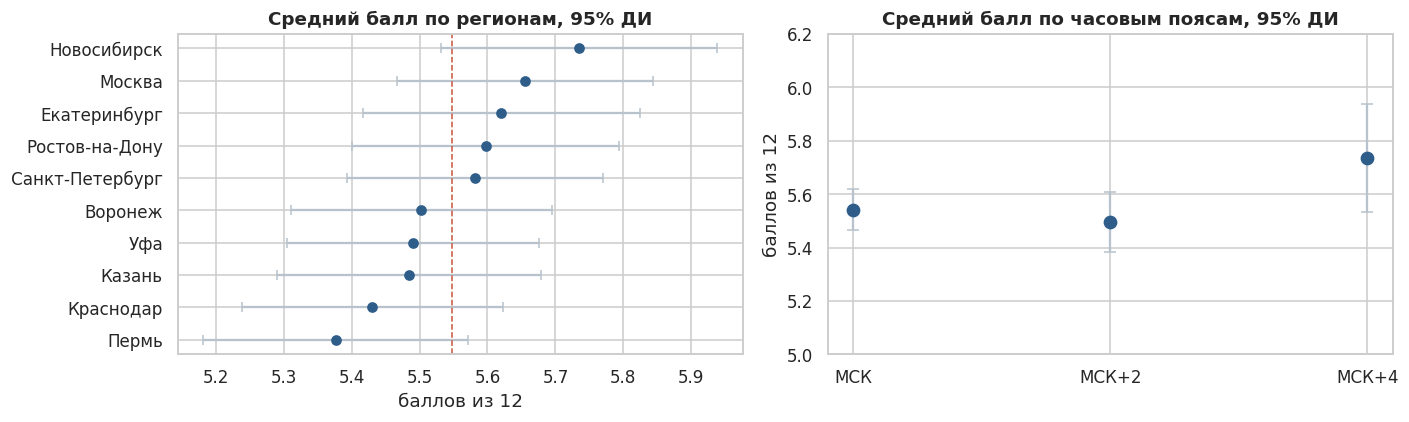

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
reg_ci = pd.DataFrame({reg: mean_ci(g["n_correct"]) for reg, g in df.groupby("region")}, index=["m", "lo", "hi"]).T.sort_values("m")
axes[0].errorbar(reg_ci["m"], reg_ci.index, xerr=[reg_ci["m"] - reg_ci["lo"], reg_ci["hi"] - reg_ci["m"]], fmt="o", color=ACCENT, ecolor=GREY, capsize=3)
axes[0].axvline(df["n_correct"].mean(), ls="--", c=WARN, lw=1)
axes[0].set(title="Средний балл по регионам, 95% ДИ", xlabel="баллов из 12")

tz_ci = pd.DataFrame({tz: mean_ci(g["n_correct"]) for tz, g in df.groupby("timezone")}, index=["m", "lo", "hi"]).T
axes[1].errorbar(tz_ci.index, tz_ci["m"], yerr=[tz_ci["m"] - tz_ci["lo"], tz_ci["hi"] - tz_ci["m"]], fmt="o", color=ACCENT, ecolor=GREY, capsize=4, ms=8)
axes[1].set(title="Средний балл по часовым поясам, 95% ДИ", ylabel="баллов из 12", ylim=(5, 6.2))
plt.tight_layout(); plt.savefig(FIG / "07_regions_tz.png", bbox_inches="tight"); plt.show()

**Что показали тесты**

* **Класс — единственный сильный фактор.** Балл растёт монотонно, ρ ≈ 0,25. Разница между 5-м и 11-м классом — около двух баллов.
* **Регионы не различаются.** Разброс средних — от 5,38 (Пермь) до 5,73 (Новосибирск), доверительные интервалы перекрываются, Краскел–Уоллис p ≈ 0,37. Рейтинг регионов по этим данным строить нельзя: он будет случайным.
* **Часовой пояс не влияет.** Новосибирцы, стартовавшие по местному времени в 13–16 часов, решили не хуже москвичей.
* **Устройство, разрывы связи, повторный вход, час старта** — различий нет. Техническая сторона платформы на результат не повлияла, и это хорошая новость для продукта.
* **Школы между собой не различаются** (p ≈ 0,7). Позиция школы в «топе» — в основном шум маленькой выборки: 10–15 учеников на школу. Топ-школ в отчётах — ориентир, а не основание для наград.

## 8. Аномалии: сводка

In [35]:
anom = pd.DataFrame([
    ["Разные написания регионов", 259, "качество ввода", "справочник регионов в форме регистрации вместо свободного поля"],
    ["Полные дубликаты записей", 37, "ETL / выгрузка", "уникальный ключ student_id на уровне хранилища"],
    ["Сверхбыстрые сессии (18–31 с на 12 заданий)", 72, "тестовые прогоны или прокликивание", "флаг test-аккаунтов, минимальное время на задание, антибот"],
    ["Вариант ответа не связан с правильностью", "все 12 заданий", "логирование / перемешивание вариантов", "логировать ID ответа, а не позицию"],
    ["Ответы быстрее 5 с внутри нормальных сессий", int((df[TIM] <= 5).sum().sum()), "угадывание отдельных задач", "мониторить долю по заданиям"],
    ["Сложные задания решаются быстрее лёгких", "задания 1, 3, 9", "ученики сдаются и угадывают", "пересмотреть формулировки / подсказки"],
], columns=["аномалия", "масштаб", "вероятная причина", "что сделать"])
anom

,аномалия,масштаб,вероятная причина,что сделать
0,Разные написания регионов,259,качество ввода,справочник регионов в форме регистрации вместо...
1,Полные дубликаты записей,37,ETL / выгрузка,уникальный ключ student_id на уровне хранилища
2,Сверхбыстрые сессии (18–31 с на 12 заданий),72,тестовые прогоны или прокликивание,"флаг test-аккаунтов, минимальное время на зада..."
3,Вариант ответа не связан с правильностью,все 12 заданий,логирование / перемешивание вариантов,"логировать ID ответа, а не позицию"
4,Ответы быстрее 5 с внутри нормальных сессий,350,угадывание отдельных задач,мониторить долю по заданиям
5,Сложные задания решаются быстрее лёгких,"задания 1, 3, 9",ученики сдаются и угадывают,пересмотреть формулировки / подсказки


## 9. Выводы для бизнеса

**Данные.** Из 8 037 строк в анализ вошли 7 928 прохождений: минус 37 дубликатов и 72 сессии, которые физически не могут быть честным решением. Опечатки в регионах исправлены без потерь — все 259 строк сопоставлены с 10 регионами.

**Сложность.** Олимпиада получилась тяжёлой: средний результат — 5,6 из 12, а 12 баллов набрали меньше 1% участников. Три задания (1, 9, 3) решают меньше трети участников — чуть выше угадывания. На них ученики тратят меньше времени, чем на лёгкие: не бьются, а сдаются. Это задания-кандидаты на пересмотр формулировок или замену.

**Возраст.** Все классы решают один вариант, и пятиклассники проигрывают одиннадцатиклассникам два балла. Для пятиклассников треть заданий — на уровне лотереи. Раздельные варианты по ступеням (5–6, 7–9, 10–11) сделают результат информативнее и снизят риск, что младшие разочаруются и больше не придут.

**Вовлечённость.** Во всех классах одинаково: ~1 100 участников на класс, ~96% отвеченных заданий, ~14 минут в олимпиаде. Олимпиаду не бросают на середине: пропущено около 4% заданий, пропуски равномерно размазаны по всем двенадцати. Хотя бы одно задание пропустили 38% участников — обычно одно. Узкое место не в удержании, а в сложности.

**Регионы.** Статистически одинаковые — и по баллам, и по поведению. Региональные рейтинги по этим данным будут шумом. Ценность региональных отчётов — в охвате (сколько школ и учеников) и в операционных метриках (разрывы, устройства), а не в соревновании.

**Платформа.** 41% проходили олимпиаду с телефона или планшета, у 17% были разрывы связи, у половины — повторный вход. На результат это не повлияло. Мобильную версию можно считать рабочей.

**Что сделать в следующем сезоне**
1. Справочник регионов вместо свободного ввода, уникальный ключ участника, флаг тестовых аккаунтов.
2. Антифрод-правило: сессия короче 2 минут или ответ быстрее 5 секунд подряд на нескольких заданиях — в отдельную очередь.
3. Логировать ID выбранного варианта, чтобы анализировать дистракторы.
4. Раздельные варианты по ступеням; задания 1, 3, 9 — на ревизию методистам.
5. Добавить в данные тип населённого пункта и регистрации — тогда можно будет проверить «город против села» и посчитать реальную конверсию в участие.

**Ограничения.** Данные похожи на синтетические: слишком ровное распределение по классам и школам, отсутствие межрегиональных различий. Выводы о поведении реальных школьников стоит перепроверить на боевой выгрузке.

In [36]:
print("Графики:", *sorted(p.name for p in FIG.glob("*.png")), sep="\n  ")

Графики:
  01_duration.png
  02_tasks.png
  03_task_grade_heatmap.png
  04_audience.png
  05_school_size.png
  06_grade_scores.png
  07_regions_tz.png
  region_Воронеж.png
  region_Екатеринбург.png
  region_Казань.png
  region_Краснодар.png
  region_Москва.png
  region_Новосибирск.png
  region_Пермь.png
  region_Ростов-на-Дону.png
  region_Санкт-Петербург.png
  region_Уфа.png
